# **Delivery Performance Optimization:**

> **`Problem`**:   
The company needs to improve its on-time delivery performance to enhance customer satisfaction and competitive advantage.

> **`Business Impact`**:   
Poor delivery performance leads to customer dissatisfaction, negative reviews, and potential loss of business to competitors.

> **`Key Questions`**:     
> 1. What is the current on-time delivery rate across different warehouse blocks?
> 2. Which factors most significantly impact delivery timeliness?
> 3. How can we predict which shipments are likely to be delayed?

In [1]:
import pandas as pd 
import numpy as np 
import warnings as war 
war.filterwarnings(action= "ignore")
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
data= pd.read_json("https://raw.githubusercontent.com/rajesh-coventry/Projects/refs/heads/master/02_Data_Visuallization/05_E-Commerce_Shipping/ecommerce_shipping_data.json")
data.shape

(10999, 12)

In [3]:
data.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


## **1. Data Exploration and Quality Assessment:**

In [4]:
# Descriptive statistics for numerical columns: 
data.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


**Outliers Detection:**

In [5]:
# Outliers Detection and save outliers in series for each column:
outliers = {}
for col in data.select_dtypes(include=['int64', 'float64']).columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers[col] = data[(data[col] < lower_bound) | (data[col] > upper_bound)].index

In [6]:
data.select_dtypes(include=['int64', 'float64']).columns

Index(['ID', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
       'Prior_purchases', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [7]:
outliers["ID"], outliers["Customer_rating"], outliers["Customer_care_calls"], outliers["Cost_of_the_Product"], outliers["Weight_in_gms"], outliers["Reached.on.Time_Y.N"]

# These columns have no outlier values

(Index([], dtype='int64'),
 Index([], dtype='int64'),
 Index([], dtype='int64'),
 Index([], dtype='int64'),
 Index([], dtype='int64'),
 Index([], dtype='int64'))

Following two columns `'Prior_purchases'` and, `"Discount_offered"`  contains outlier values:

In [8]:
out1= outliers["Prior_purchases"]
out1= out1.to_frame(name= "out11")
out1.head(3)

,out11
37,37
62,62
74,74


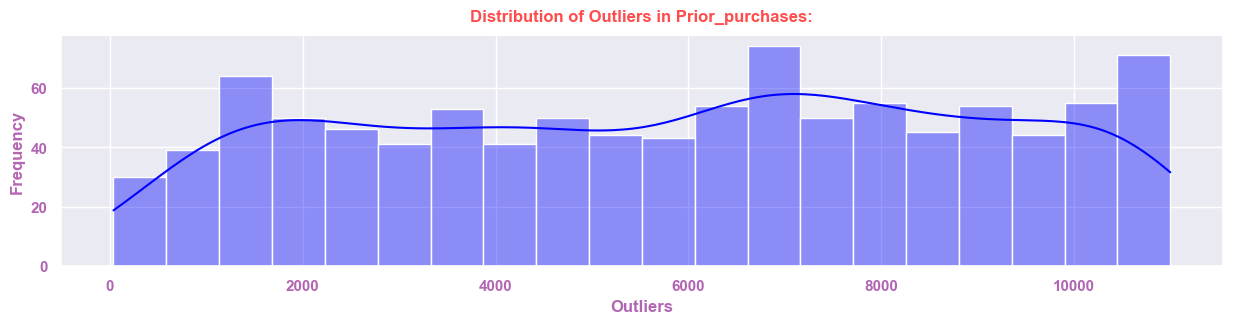

In [9]:
plt.figure(figsize=(15, 3))
sns.set_theme(context="notebook", style="darkgrid")
sns.histplot(data=out1, x="out11", kde=True, bins=20, color= "blue", alpha=0.4)
plt.title("Distribution of Outliers in Prior_purchases:", fontsize=12, fontweight="bold", color="Red", pad=10, alpha=0.7)
plt.xlabel("Outliers", color="purple", fontweight="bold", alpha=0.6)
plt.ylabel("Frequency", color="purple", fontweight="bold", alpha=0.6)    
plt.xticks(alpha=0.6, color="purple", fontweight="bold")
plt.yticks(alpha=0.6, color="purple", fontweight="bold")
plt.show()

In [10]:
outliers["Discount_offered"]
out2= outliers["Discount_offered"].to_frame(name= "out22")
out2.head(3)

,out22
0,0
1,1
2,2


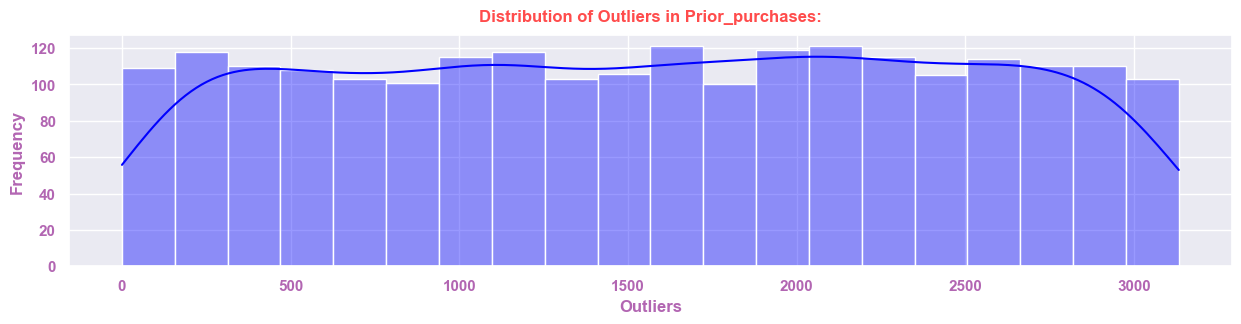

In [11]:
plt.figure(figsize=(15, 3))
sns.set_theme(context="notebook", style="darkgrid")
sns.histplot(data=out2, x="out22", kde=True, bins=20, alpha= 0.4, color= "blue")
plt.title("Distribution of Outliers in Prior_purchases:", fontsize=12, fontweight="bold", color="Red", pad=10, alpha=0.7)
plt.xlabel("Outliers", color="purple", fontweight="bold", alpha=0.6)
plt.ylabel("Frequency", color="purple", fontweight="bold", alpha=0.6)    
plt.xticks(alpha=0.6, color="purple", fontweight="bold")
plt.yticks(alpha=0.6, color="purple", fontweight="bold")
plt.show()

**Box plots for the distribution of all numeric columns:**

In [12]:
data.select_dtypes(include=['int64', 'float64']).columns

Index(['ID', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
       'Prior_purchases', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

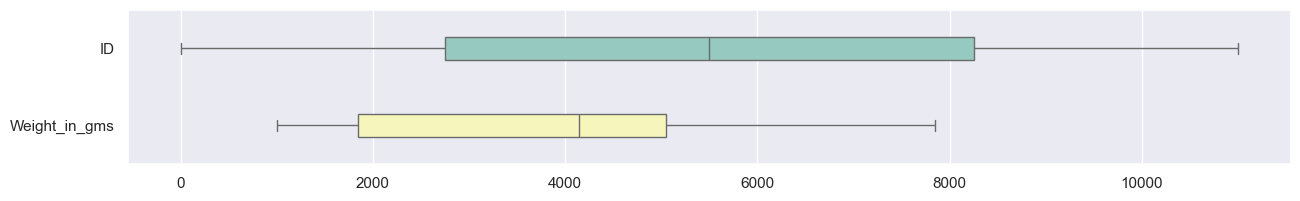

In [13]:
# Box plot for the distribution of all numeric columns:
plt.figure(figsize=(15, 2))
sns.set_theme(context="notebook", style="darkgrid")
sns.boxplot(data=data[["ID", "Weight_in_gms"]], orient="h", palette="Set3", width= 0.3)
plt.show()

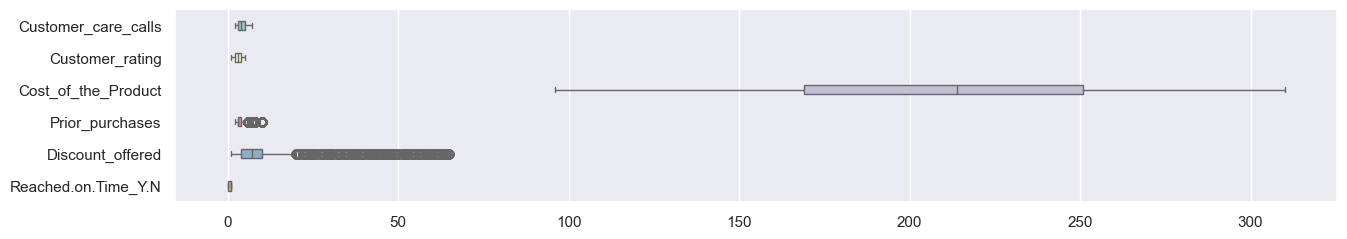

In [14]:
plt.figure(figsize=(15, 2.5))
sns.set_theme(context="notebook", style="darkgrid")
sns.boxplot(data=data[['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
       'Prior_purchases', 'Discount_offered',
       'Reached.on.Time_Y.N']], orient="h", palette="Set3", width= 0.3)
plt.show()

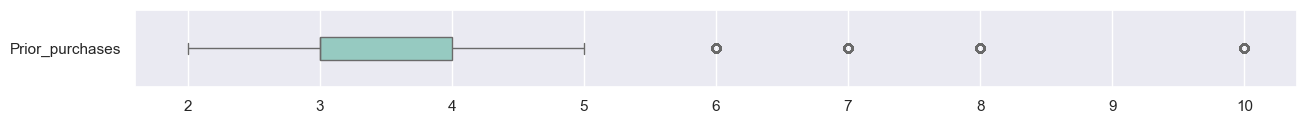

In [15]:
plt.figure(figsize=(15, 1))
sns.set_theme(context="notebook", style="darkgrid")
sns.boxplot(data=data[['Prior_purchases']], orient="h", palette="Set3", width= 0.3)
plt.show()

<Axes: >

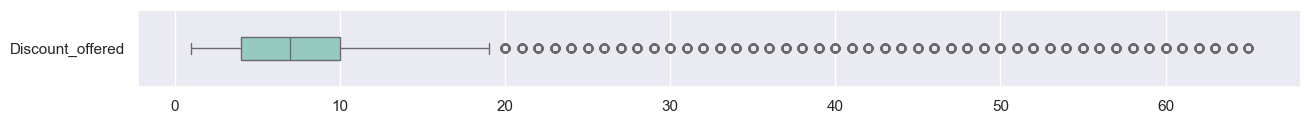

In [16]:
plt.figure(figsize=(15, 1))
sns.set_theme(context="notebook", style="darkgrid")
sns.boxplot(data=data[['Discount_offered']], orient="h", palette="Set3", width= 0.3)

-----
-----
-----
-----
---

## **2. Overall Delivery Performance Baseline:**

In [17]:
data.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


In [18]:
data["Reached.on.Time_Y.N"].value_counts().reset_index()

,Reached.on.Time_Y.N,count
0,1,6563
1,0,4436


In [19]:
current_on_time_delivery_rate= round((data["Reached.on.Time_Y.N"].value_counts().reset_index().loc[0, "count"] / data.shape[0]) * 100, 2)
print(F'Current on-time Delivery Rate is: {current_on_time_delivery_rate}') 

Current on-time Delivery Rate is: 59.67


Current on-time delivery rate is about 60%.

In [20]:
# Summary statistics for on-time deliveries:
data[data["Reached.on.Time_Y.N"]== 1].describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,6563.000000,6563.000000,6563.000000,6563.000000,6563.000000,6563.000000,6563.000000,6563.0
mean,4424.978364,3.991467,3.005790,207.289197,3.498095,18.663721,3272.640104,1.0
std,3243.986559,1.122592,1.412692,48.054876,1.517285,19.108797,1576.148391,0.0
min,1.000000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,1.0
25%,1641.500000,3.000000,2.000000,167.000000,3.000000,5.000000,1735.500000,1.0
50%,3467.000000,4.000000,3.000000,209.000000,3.000000,9.000000,3231.000000,1.0
75%,7194.500000,5.000000,4.000000,249.000000,4.000000,32.000000,4696.500000,1.0
max,10995.000000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.0


**Statistics for `on_time_deliveries`:**
* Customers make about 4 customer care calls on average.

* Average customer rating is roughly 3 out of 5.
* Mean product cost is around 207 units.
* Customers typically make 3 to 4 prior purchases.
* Average discount offered is nearly $18.66.
* Products weigh about 3273 grams on average.
* All deliveries reached on time (mean is 1.0).

In [21]:
data.sample(10)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
8541,8542,B,Ship,4,4,224,10,medium,F,9,4149,0
980,981,A,Ship,4,4,209,3,low,F,44,2075,1
821,822,F,Flight,2,1,98,3,low,F,29,1806,1
8241,8242,B,Ship,4,5,208,3,low,F,8,4632,0
1973,1974,F,Ship,5,1,201,3,medium,M,19,2696,1
6890,6891,A,Ship,6,3,247,4,medium,M,3,1903,0
6582,6583,D,Flight,7,2,279,4,medium,F,1,1480,0
7972,7973,C,Ship,4,3,239,2,medium,F,7,5384,0
10171,10172,F,Ship,6,2,137,10,low,F,4,4490,0
4307,4308,F,Ship,4,5,135,3,medium,F,6,5266,1


In [22]:
# Summary statistics for off-time deliveries:
data[data["Reached.on.Time_Y.N"]== 0].describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,4436.000000,4436.000000,4436.000000,4436.000000,4436.000000,4436.000000,4436.000000,4436.0
mean,7090.479486,4.147656,2.967989,214.498647,3.670424,5.545987,4168.668395,0.0
std,2278.543555,1.162771,1.414808,47.757432,1.525444,2.877727,1573.954178,0.0
min,3136.000000,2.000000,1.000000,97.000000,2.000000,1.000000,1001.000000,0.0
25%,5092.250000,3.000000,2.000000,174.000000,3.000000,3.000000,4043.500000,0.0
50%,7096.000000,4.000000,3.000000,222.000000,3.000000,6.000000,4674.000000,0.0
75%,9078.500000,5.000000,4.000000,254.000000,4.000000,8.000000,5337.000000,0.0
max,10999.000000,7.000000,5.000000,310.000000,10.000000,10.000000,6000.000000,0.0


**Statistics for `not_on_time_deliveries`:**

* Customers made about 4.15 calls on average.

* Average customer rating is approximately 3 out of 5.
* Product cost averages around 214 units.
* Customers made nearly 3.7 prior purchases.
* Average discount offered is about $5.5.
* Product weight averages around 4169 grams.

----
---
---
---
----
----
---

## **3. Warehouse Block Performance Analysis:**

In [23]:
data.columns 

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [24]:
# Warehouse and shipments from each of the house:
nan= data["Warehouse_block"].value_counts()
nan

Warehouse_block
F    3666
D    1834
A    1833
B    1833
C    1833
Name: count, dtype: int64

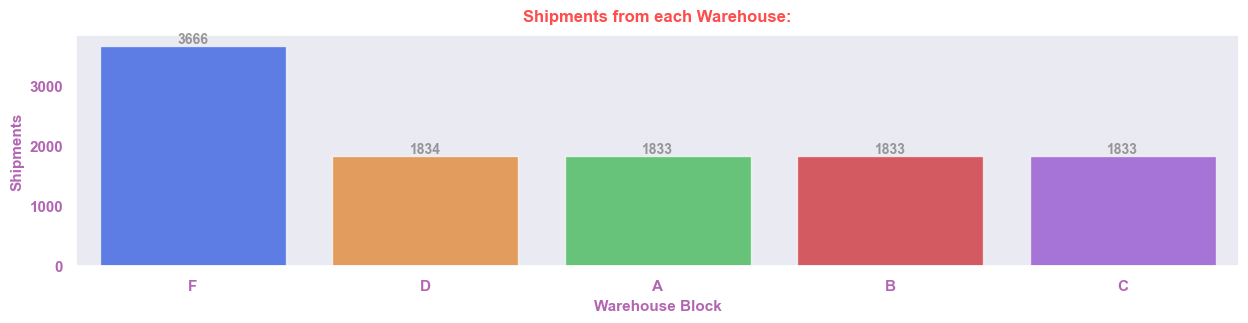

In [25]:
plt.figure(figsize=(15, 3))
sns.set_theme(context="notebook", style="dark")
sns.barplot(x= nan.index, y= nan.values, palette="bright", alpha= 0.7)
plt.title("Shipments from each Warehouse:", fontsize=12, fontweight="bold", color="Red", pad=10, alpha=0.7) 
plt.xlabel("Warehouse Block", color="purple", fontweight="bold", alpha=0.6, fontsize= 11)
plt.ylabel("Shipments", color="purple", fontweight="bold", alpha=0.6, fontsize= 11)
plt.xticks(color= "purple", fontweight="bold", alpha=0.6, fontsize= 11) 
plt.yticks(color= "purple", fontweight="bold", alpha=0.6, fontsize= 11)
# add annotations to the bars
for i, v in enumerate(nan.values):
    plt.text(i, v, str(v), ha='center', va='bottom', fontweight='bold', fontsize= 10, color="gray", alpha=0.8)
plt.show()

In [26]:
rat= data.groupby("Warehouse_block")["Reached.on.Time_Y.N"].value_counts().reset_index(name= "count")
rat

,Warehouse_block,Reached.on.Time_Y.N,count
0,A,1,1075
1,A,0,758
2,B,1,1104
3,B,0,729
4,C,1,1094
5,C,0,739
6,D,1,1096
7,D,0,738
8,F,1,2194
9,F,0,1472


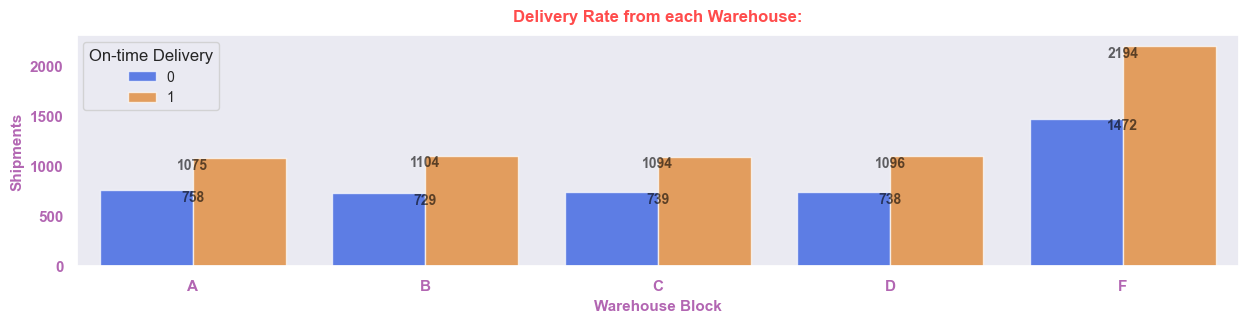

In [27]:
plt.figure(figsize=(15, 3))
sns.set_theme(context="notebook", style="dark")
sns.barplot(x= rat["Warehouse_block"], y= rat["count"], hue= rat["Reached.on.Time_Y.N"], palette="bright", alpha= 0.7)
plt.title("Delivery Rate from each Warehouse:", fontsize=12, fontweight="bold", color="Red", pad=10, alpha=0.7)
plt.xlabel("Warehouse Block", color="purple", fontweight="bold", alpha=0.6, fontsize= 11)
plt.ylabel("Shipments", color="purple", fontweight="bold", alpha=0.6, fontsize= 11)
plt.xticks(color= "purple", fontweight="bold", alpha=0.6, fontsize= 11)
plt.yticks(color= "purple", fontweight="bold", alpha=0.6, fontsize= 11)
plt.legend(title= "On-time Delivery", loc= "upper left", fontsize= 10)

# Add annotations for each bar group
for i in range(len(rat["Warehouse_block"].unique())):
    for j in range(len(rat["Reached.on.Time_Y.N"].unique())):
        index = i * len(rat["Reached.on.Time_Y.N"].unique()) + j
        value = rat.iloc[index]["count"]
        plt.text(i, value, str(value), ha='center', va='top', fontweight='bold', fontsize=10, color="black", alpha=0.6)

plt.show()

In [28]:
# compute the propersion of on-time deliveries for each warehouse block
rat["proportion"] = rat.groupby("Warehouse_block")["count"].transform(lambda x: x / x.sum())

In [29]:
rat

,Warehouse_block,Reached.on.Time_Y.N,count,proportion
0,A,1,1075,0.586470
1,A,0,758,0.413530
2,B,1,1104,0.602291
3,B,0,729,0.397709
4,C,1,1094,0.596836
5,C,0,739,0.403164
6,D,1,1096,0.597601
7,D,0,738,0.402399
8,F,1,2194,0.598472
9,F,0,1472,0.401528


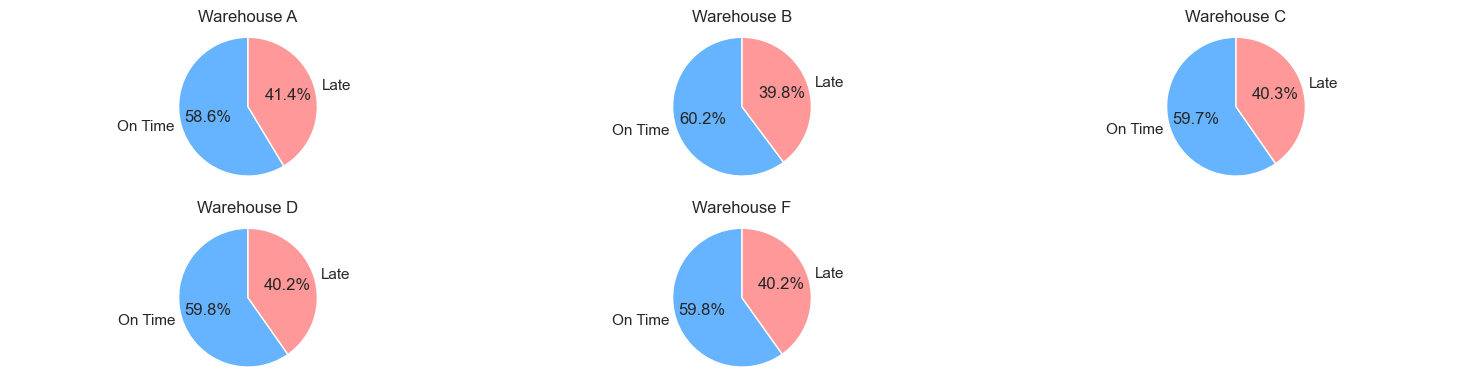

In [30]:
import math 
# Get unique warehouses
warehouses = rat['Warehouse_block'].unique()
n_warehouses = len(warehouses)

# Subplot grid dimensions
n_cols = 3
n_rows = math.ceil(n_warehouses / n_cols)

# Create figure and axes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 2))
axes = axes.flatten()  # Flatten in case of single row

# Loop through each warehouse and plot
for i, block in enumerate(warehouses):
    subset = rat[rat['Warehouse_block'] == block]
    sizes = subset['count'].values
    labels = ['On Time', 'Late']
    colors = ['#66b3ff', '#ff9999']

    axes[i].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    axes[i].set_title(f'Warehouse {block}')
    axes[i].axis('equal')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

* **`Warehouse A`**: 58.6% deliveries were on time, 41.4% were late

* **`Warehouse B`**: Has the highest on-time rate at 60.2%
* **`Warehouse C`**: 59.7% on-time; slightly better than Warehouse A
* **`Warehouse D`**: Same on-time rate as Warehouse C at 59.8%
* **`Warehouse F`**: Also 59.8% on-time, equal to Warehouse D
* **`All warehouses`**: On-time delivery rate is consistently around 59–60%
* **`Late deliveries`**: Range from 39.8% to 41.4% across all warehouses
* **`Warehouse A`**: Has the highest late delivery rate among all
* **`Warehouse B`**: Most efficient in terms of timely deliveries

**Statistical significance tests to identify meaningful differences between warehouses:**

To statistically compare the delivery performance between **`warehouses`** (based on on-time vs. late deliveries), we can treat this as a **`test of proportions`** or a **`chi-squared test`** for categorical data.

If we want to check if the **proportion of on-time deliveries differs significantly** between warehouses then;

   * **Null Hypothesis $(H₀)$:**
     The proportion of on-time deliveries is the **same** in Warehouse A and Warehouse B.

   * **Alternative Hypothesis $(H₁)$:**
    The proportion of on-time deliveries is **different** between Warehouse A and Warehouse B.

We use:
* **`Chi-Square Test of Independence`** for all warehouses at once.

* **`Two-proportion z-test`** for pairwise comparisons.

In [31]:
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

**Pivot for Chi-Square Test:**

In [32]:
pivot = rat.pivot(index='Warehouse_block', columns='Reached.on.Time_Y.N', values='count')
pivot.columns = ['Late', 'OnTime']  # 0 = Late, 1 = OnTime
pivot = pivot[['OnTime', 'Late']]  # reorder
pivot

,OnTime,Late
Warehouse_block,,
A,1075,758
B,1104,729
C,1094,739
D,1096,738
F,2194,1472


**Chi-Square Test (all warehouses):**

In [33]:
chi2, p, dof, expected = chi2_contingency(pivot.values)

print(f"Chi-squared Test Statistic: {chi2:.4f}")
print(f"p-value: {p:.4f}")

if p < 0.05:
    print("Reject the null hypothesis: Significant differences exist between warehouses.")
else:
    print("Fail to reject the null: No significant differences between warehouses.")

Chi-squared Test Statistic: 1.0894
p-value: 0.8960
Fail to reject the null: No significant differences between warehouses.


> Even though we have slight difference in proportion for `on-time` deliveries for different warehouses, statistical test suggests that there is no significant difference between the `on_time_deliveries` between warehouses and the small differences observed are due to random nature of the process. 

**Pairwise Proportion Z-tests:**

`Example`: A vs B:

In [34]:
# On-time counts
success = np.array([1075, 1104])
# Total deliveries
nobs = np.array([1075+758, 1104+729])

stat, pval = proportions_ztest(success, nobs)
print(f"Proportion z-test A vs B: p-value = {pval:.4f}")

Proportion z-test A vs B: p-value = 0.3293


> Fail to reject null hypothesis $(H_0)$ and so there is no significant difference between `proportions of on_time_deliveris` between warehouse A and B.

`Example`: B vs F:

In [35]:
pivot

,OnTime,Late
Warehouse_block,,
A,1075,758
B,1104,729
C,1094,739
D,1096,738
F,2194,1472


In [36]:
# On-time counts
success = np.array([1104, 2194])
# Total deliveries
nobs = np.array([1104+729, 2194+1472])

stat, pval = proportions_ztest(success, nobs)
print(f"Proportion z-test B vs F: p-value = {pval:.4f}")

Proportion z-test B vs F: p-value = 0.7853


> Fail to reject null hypothesis ($H_0$) and so there is no significant difference between `proportions of on time deliveris` between warehouse B and F.

**Decision Criteria:** 

> * **$p < 0.05$** → Significant difference (reject H₀)
> * **$p ≥ 0.05$** → No significant difference (fail to reject H₀)

Since, from calculations, difference between warehous B and F was largest among all the warehouses and statistical test suggests these differences are the results of rando nature of the process; overall, proportion `on_time_delivery` for all warehouses is same.

----
-----
-----
-----
----

## **4. Shipping Mode Effectiveness Analysis:**

In [37]:
data.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


In [38]:
data["Mode_of_Shipment"].nunique()

3

In [39]:
data["Mode_of_Shipment"].unique()

array(['Flight', 'Ship', 'Road'], dtype=object)

In [40]:
prop_of_mode_of_ship= data["Mode_of_Shipment"].value_counts(normalize=True).reset_index(name= "proportion")
prop_of_mode_of_ship

,Mode_of_Shipment,proportion
0,Ship,0.678425
1,Flight,0.161560
2,Road,0.160015


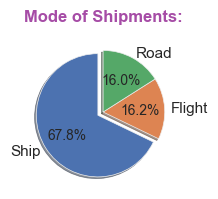

In [41]:
plt.figure(figsize=(2, 2))
# set theme for matplotlib plot using matplotlib
plt.style.use("ggplot") 
plt.pie(x= prop_of_mode_of_ship["proportion"], labels= prop_of_mode_of_ship["Mode_of_Shipment"], autopct= "%1.1f%%", shadow= True, startangle= 90, explode= (0.1, 0, 0), colors= sns.color_palette("deep"))
plt.title("Mode of Shipments:", fontsize= 12, fontweight= "bold", color= "purple", pad= 10, alpha= 0.7)
plt.show()

* Ship accounts for the majority at 67.8%.

* Flight makes up 16.2% of shipments.
* Road accounts for 16.0% of shipments.
* Shipments by ship are significantly more common.
* Road and flight shipments have nearly equal shares.
* Flight has a slightly larger share than road.

#### **`Hypothesis Test`:** *To Test if Shipments by ship are significantly higher or not:*

We want to test whether the proportion of **Ship shipments** is significantly greater than the **average of others**.

Let:

* $p_{ship}$ = proportion of shipments by ship
* $p_{others}$ = average proportion of shipments by road and flight

**Null Hypothesis (H₀):** $p_{ship} \leq p_{others}$ : (Shipments by ship are not significantly higher)

**Alternative Hypothesis:** (H₁): $p_{ship} > p_{others}$: (Shipments by ship are significantly higher)

Since we're comparing one proportion against a reference proportion (others combined), use a **one-sample Z-test for proportion**.

**The test statistic is:**

$$
Z = \frac{p_{ship} - p_0}{\sqrt{\frac{p_0 (1 - p_0)}{n}}}
$$

Where:

* $p_{ship} = 0.678$
* $p_0 = \frac{0.160 + 0.162}{2} = 0.161$
* $n$ = total sample size (need this to compute standard error)

In [42]:
data.shape[0]

10999

In [43]:
from statsmodels.stats.proportion import proportions_ztest

# Observed count for ship
count = 7455          # Ship count
nobs = 10999          # Total shipments

# Hypothesized proportion (average of road and flight)
p_null = (0.160 + 0.162) / 2

# Perform one-sample z-test for proportion
stat, pval = proportions_ztest(count, nobs, value=p_null, alternative='larger')

print(f"Z-statistic: {stat:.2f}, p-value: {pval:.20f}")

Z-statistic: 115.98, p-value: 0.00000000000000000000


> **Decision Rule:**
> 
> * If **p-value < α (e.g., 0.05)** → reject H₀ → shipment by ship is **significantly higher**
> * If **p-value ≥ α** → fail to reject H₀ → no significant evidence

> There is a significant evidence to `Reject Null Hypothesis` and we conclude that; `Shipments by Ship are significantly higher than the other modes.`  

In [44]:
data.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


**Find out the overall contribution in shipping by each of the shipping approach:**

In [45]:
number_shipments= data.shape[0]
# Contribution on total shipment by each shipping approach: 
prop_of_ships_by_flight= (data[data["Mode_of_Shipment"]== "Flight"].shape[0])/ number_shipments * 100
prop_of_ships_by_road=  (data[data["Mode_of_Shipment"]== "Road"].shape[0])/number_shipments * 100
prop_of_ships_by_ocean= (data[data["Mode_of_Shipment"]== "Ship"].shape[0])/number_shipments * 100
prop_series= pd.Series([prop_of_ships_by_flight, prop_of_ships_by_road, prop_of_ships_by_ocean], index= ["Flight", "Road", "Ship"]).T
prop_series

Flight    16.156014
Road      16.001455
Ship      67.842531
dtype: float64

In [46]:
sns.color_palette(as_cmap=True)

['#E24A33', '#348ABD', '#988ED5', '#777777', '#FBC15E', '#8EBA42', '#FFB5B8']

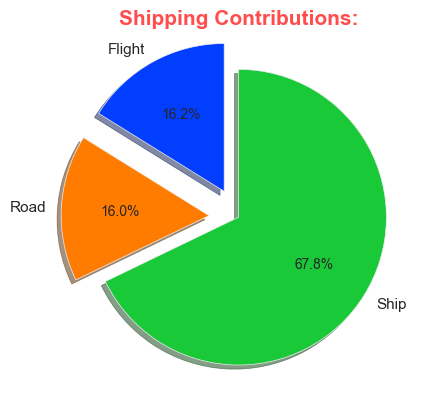

In [47]:
plt.pie(x= prop_series, labels= prop_series.index, autopct= "%1.1f%%", shadow= True, explode= (0.2, 0.2, 0), startangle= 90, colors= sns.color_palette("bright"))
plt.title("Shipping Contributions:", color= "Red", alpha= 0.7, fontweight= "bold", fontsize= 15)
plt.show()

In [48]:
data.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


In [49]:
data.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [50]:
ot_mos= data.groupby("Mode_of_Shipment")["Reached.on.Time_Y.N"].value_counts(normalize=True).reset_index()
ot_mos

,Mode_of_Shipment,Reached.on.Time_Y.N,proportion
0,Flight,1,0.601576
1,Flight,0,0.398424
2,Road,1,0.588068
3,Road,0,0.411932
4,Ship,1,0.597561
5,Ship,0,0.402439


In [51]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

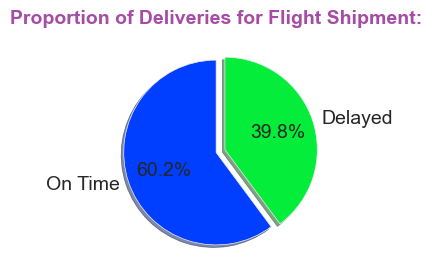

In [52]:
plt.figure(figsize=(3, 3))
plt.style.use("seaborn-v0_8-bright")
plt.pie(x=ot_mos[ot_mos["Mode_of_Shipment"]=="Flight"]["proportion"], 
        explode=[0, 0.1],
        labels=["On Time", "Delayed"],  # Added descriptive labels
        autopct=lambda pct: f'{pct:.1f}%',  # Dynamic percentage formatting
        shadow=True,
        startangle=90,
        textprops={'fontsize': 14})  # Increased font size for better visibility

plt.title("Proportion of Deliveries for Flight Shipment:", fontsize=14, fontweight="bold", color="purple", pad=10, alpha=0.7) 
plt.show()

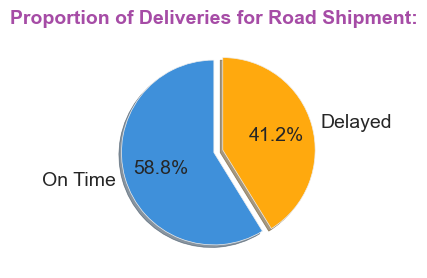

In [53]:
plt.figure(figsize=(3, 3))
plt.style.use("petroff10")
plt.pie(x=ot_mos[ot_mos["Mode_of_Shipment"]=="Road"]["proportion"], 
        explode=[0, 0.1],
        labels=["On Time", "Delayed"],  # Added descriptive labels
        autopct=lambda pct: f'{pct:.1f}%',  # Dynamic percentage formatting
        shadow=True,
        startangle=90,
        textprops={'fontsize': 14})  # Increased font size for better visibility

plt.title("Proportion of Deliveries for Road Shipment:", fontsize=14, fontweight="bold", color="purple", pad=10, alpha=0.7) 
plt.show()

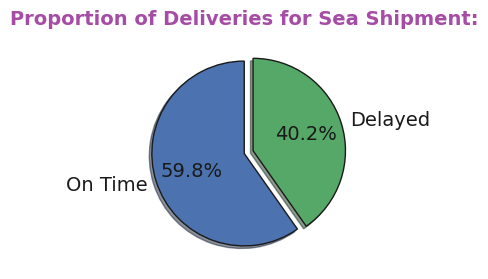

In [54]:
plt.figure(figsize=(3, 3))
plt.style.use("classic")
plt.pie(x=ot_mos[ot_mos["Mode_of_Shipment"]=="Ship"]["proportion"], 
        explode=[0, 0.1],
        labels=["On Time", "Delayed"],  # Added descriptive labels
        autopct=lambda pct: f'{pct:.1f}%',  # Dynamic percentage formatting
        shadow=True,
        startangle=90,
        textprops={'fontsize': 14})  # Increased font size for better visibility

plt.title("Proportion of Deliveries for Sea Shipment:", fontsize=14, fontweight="bold", color="purple", pad=10, alpha=0.7) 
plt.show()

In [55]:
data.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


In [56]:
# Group by 'Mode_of_Shipment' and calculate on-time rates
on_time_rates = data.groupby('Mode_of_Shipment')['Reached.on.Time_Y.N'].mean().reset_index()
on_time_rates.rename(columns={'Reached.on.Time_Y.N': 'On_Time_Rate'}, inplace=True)
on_time_rates

,Mode_of_Shipment,On_Time_Rate
0,Flight,0.601576
1,Road,0.588068
2,Ship,0.597561


In [57]:
# Calculate average 'Cost_of_the_Product' for each shipping mode
avg_cost = data.groupby('Mode_of_Shipment')['Cost_of_the_Product'].mean().reset_index()
avg_cost.rename(columns={'Cost_of_the_Product': 'Avg_Cost_of_Product'}, inplace=True)
avg_cost

,Mode_of_Shipment,Avg_Cost_of_Product
0,Flight,209.306697
1,Road,210.475568
2,Ship,210.343072


In [58]:
# Merge for combined view
summary = pd.merge(on_time_rates, avg_cost, on='Mode_of_Shipment')
summary

,Mode_of_Shipment,On_Time_Rate,Avg_Cost_of_Product
0,Flight,0.601576,209.306697
1,Road,0.588068,210.475568
2,Ship,0.597561,210.343072


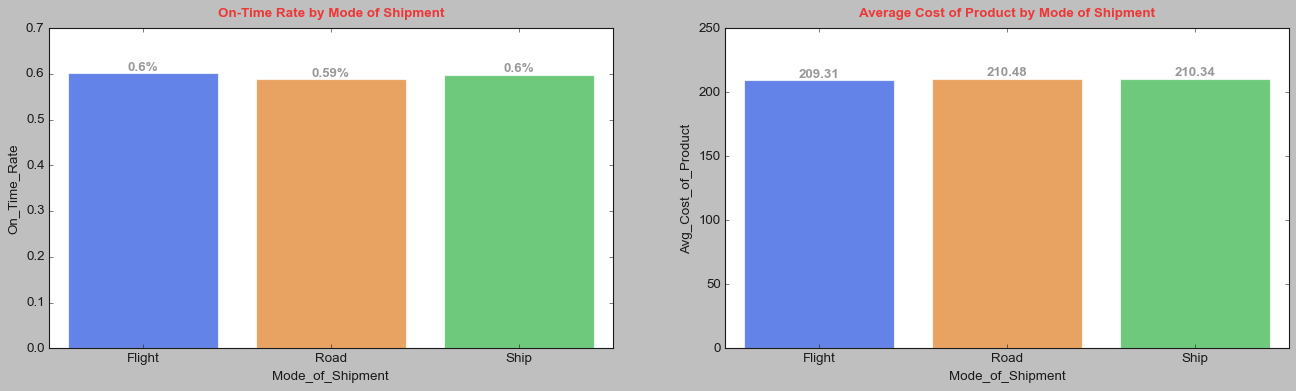

In [59]:
war.filterwarnings(action= "ignore")
# Visualize: Barplot for on-time rate and average cost
fig, ax1 = plt.subplots(1, 2, figsize=(20, 5))
sns.set_theme(context="notebook", style="darkgrid")  # Set the style
# Barplot for on-time rate
sns.barplot(data= summary, x= "Mode_of_Shipment", y= "On_Time_Rate", palette="bright", alpha= 0.7, ax= ax1[0])
# add annotations to the bars
for i, v in enumerate(summary["On_Time_Rate"]):
    ax1[0].text(i, v, f'{round(v, 2)}%', ha='center', va='bottom', fontweight='bold', fontsize= 12, color="gray", alpha=0.8)  

ax1[0].set_title("On-Time Rate by Mode of Shipment", fontsize=12, fontweight="bold", color="Red", pad=10, alpha=0.7)

# Visualising on-time rate and average cost
sns.barplot(data= summary, y= "Avg_Cost_of_Product", x= "Mode_of_Shipment", palette="bright", alpha= 0.7, ax= ax1[1])
ax1[1].set_title("Average Cost of Product by Mode of Shipment", fontsize=12, fontweight="bold", color="Red", pad=10, alpha=0.7)
# Add annotations to the bars
for i, v in enumerate(summary["Avg_Cost_of_Product"]):
    ax1[1].text(i, v, f'{round(v, 2)}', ha='center', va='bottom', fontweight='bold', fontsize= 12, color="gray", alpha=0.8) 

plt.show()

#### **`Hypothesis Test`: Which shipping Mode is cost effective:**

Test if **Flight**, **Road**, or **Ship** has a significantly **lower average cost** than others.

From the table `summary`, **`Flight`** has the lowest average cost, so we will test whether it's significantly lower than the others.

We'll use **`two-sample t-tests`** to compare average cost of **`Flight`** vs each of the others:

**1. `Hypothesis`: Flight vs Road:**

* **H₀**: $\mu_{Flight} \geq \mu_{Road}$
* **H₁**: $\mu_{Flight} < \mu_{Road}$ (Flight is cheaper)

**2. `Hypothesis`: Flight vs Ship:**

* **H₀**: $\mu_{Flight} \geq \mu_{Ship}$
* **H₁**: $\mu_{Flight} < \mu_{Ship}$ (Flight is cheaper)

In [60]:
number_shipments

10999

In [61]:
from scipy.stats import ttest_ind

# Hypothetical samples of product costs: 
flight_costs = data[data["Mode_of_Shipment"]== "Flight"]["Cost_of_the_Product"]
road_costs = data[data["Mode_of_Shipment"]== "Road"]["Cost_of_the_Product"]
ship_costs = data[data["Mode_of_Shipment"]== "Ship"]["Cost_of_the_Product"]

# t-test: one-sided, Flight < Road
t_stat1, p_val1 = ttest_ind(flight_costs, road_costs, alternative='less')

# t-test: one-sided, Flight < Ship
t_stat2, p_val2 = ttest_ind(flight_costs, ship_costs, alternative='less')

print(f"Flight vs Road: p-value = {p_val1:.4f}")
print(f"Flight vs Ship: p-value = {p_val2:.4f}")

Flight vs Road: p-value = 0.2341
Flight vs Ship: p-value = 0.2074


> **Interpretation:** 
> 
> * If p-value < 0.05 → Flight is significantly cheaper.
> * If p-value ≥ 0.05 → No significant cost difference.

Based on means, there is no enough evidence to reject Null Hypothesis. So, there is no significant difference in the cost of shipments by air or road or by bus.

----
---
----
---
-----

## **5. Product Characteristic Impact Analysis:**

> `Examine how product-related factors (importance, weight, cost) influence delivery performance.`   

In [62]:
data.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [63]:
data.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


**Product Specific factors:** `Product_importance`, `Weight_in_gms`, `Cost_of_the_Product` and, `Discount_offered`. We will study one by one relation of these variables with `delivery` factor.

In [64]:
data["Product_importance"].unique()

array(['low', 'medium', 'high'], dtype=object)

In [65]:
data["Reached.on.Time_Y.N"].unique()

array([1, 0])

In [66]:
apt= data.groupby(by= "Product_importance")["Reached.on.Time_Y.N"].value_counts(normalize=True).reset_index(name= "count").round(4)
apt

,Product_importance,Reached.on.Time_Y.N,count
0,high,1,0.6498
1,high,0,0.3502
2,low,1,0.5928
3,low,0,0.4072
4,medium,1,0.5905
5,medium,0,0.4095


In [67]:
apt[apt["Product_importance"]== "high"]["Reached.on.Time_Y.N"]

0    1
1    0
Name: Reached.on.Time_Y.N, dtype: int64

Text(0.5, 1.0, 'Low Importance Products:')

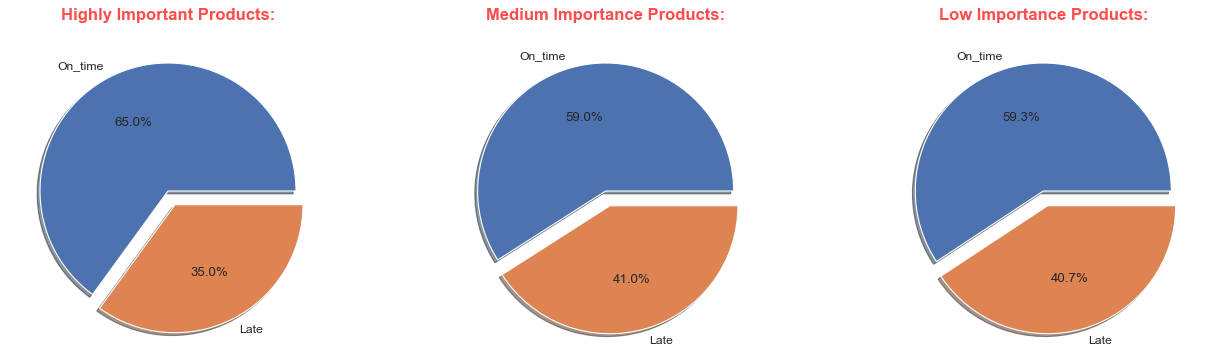

In [68]:
plt.style.use("seaborn-v0_8-darkgrid")
# create three subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes = axes.flatten()
# plot the first subplot
axes[0].pie(x= apt[apt["Product_importance"]== "high"]["count"], explode= [0, 0.12], labels= ["On_time", "Late"], shadow=True, autopct= '%1.1f%%', )
axes[0].set_title("Highly Important Products:", fontsize= 15, fontweight="bold", color="Red", pad=10, alpha=0.7)

axes[1].pie(x= apt[apt["Product_importance"]== "medium"]["count"], explode= [0, 0.12], labels= ["On_time", "Late"], shadow=True, autopct= '%1.1f%%', )
axes[1].set_title("Medium Importance Products:", fontsize= 15, fontweight="bold", color="Red", pad=10, alpha=0.7)

axes[2].pie(x= apt[apt["Product_importance"]== "low"]["count"], explode= [0, 0.12], labels= ["On_time", "Late"], shadow=True, autopct= '%1.1f%%', )
axes[2].set_title("Low Importance Products:", fontsize= 15, fontweight="bold", color="Red", pad=10, alpha=0.7)


**Study the relation between the weight of the product and on-time-delivery:**

In [69]:
data["Reached.on.Time_Y.N"].value_counts().reset_index()

,Reached.on.Time_Y.N,count
0,1,6563
1,0,4436


In [70]:
data["Reached.on.Time_Y.N"].dtype

dtype('int64')

In [71]:
data["Weight_in_gms"].dtype

dtype('int64')

In [72]:
data[["Weight_in_gms", "Reached.on.Time_Y.N"]].head(4)

,Weight_in_gms,Reached.on.Time_Y.N
0,1233,1
1,3088,1
2,3374,1
3,1177,1


In [73]:
a= data.groupby(by= "Reached.on.Time_Y.N")["Weight_in_gms"].mean().reset_index()
a

,Reached.on.Time_Y.N,Weight_in_gms
0,0,4168.668395
1,1,3272.640104


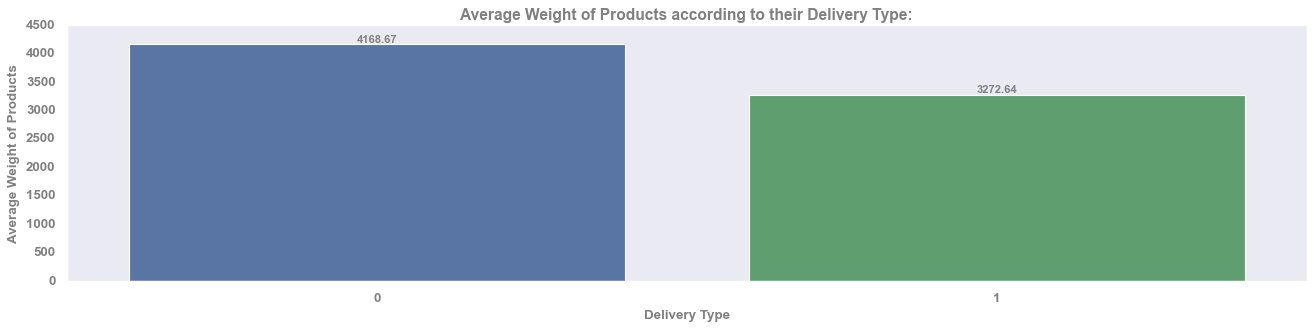

In [74]:
plt.figure(figsize=(20, 4))
sns.set_theme(context="notebook", style="dark")
sns.barplot(data= a, x= "Reached.on.Time_Y.N", y= "Weight_in_gms", palette= "deep6", )
plt.title("Average Weight of Products according to their Delivery Type:", color= "gray", fontsize= 14, fontweight= "bold")
plt.xlabel("Delivery Type", color= "gray", fontsize= 12, fontweight= "bold")    
plt.ylabel("Average Weight of Products", color= "gray", fontsize= 12, fontweight= "bold" )
plt.xticks(color= "gray", fontsize= 12, fontweight= "bold")
plt.yticks(color= "gray", fontsize= 12, fontweight= "bold")
# Add annotations to the bars
for i, v in enumerate(a["Weight_in_gms"]):
    plt.text(i, v, round((v), 2), ha='center', va='bottom', fontweight='bold', fontsize= 10, color="gray", alpha=0.99)  
plt.show()

In [75]:
a

,Reached.on.Time_Y.N,Weight_in_gms
0,0,4168.668395
1,1,3272.640104


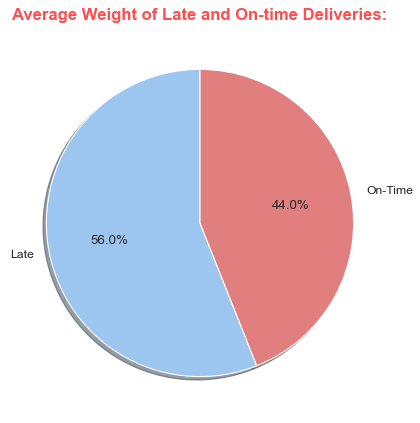

In [76]:
plt.pie(x= a["Weight_in_gms"], normalize=True, labels= ["Late", "On-Time"], autopct= "%1.1f%%", shadow= True, startangle= 90, colors= ["#9cc5ef", "#e17f7f"]) 
plt.title("Average Weight of Late and On-time Deliveries:", fontsize=15, fontweight="bold", color="Red", pad=10, alpha=0.7)
plt.show()

* Late deliveries account for **`56%`** of the average delivery weight.

* On-time deliveries contribute **`44%`** of the average delivery weight.
* Late deliveries tend to carry **`heavier loads`** than on-time ones.
* There is a noticeable **`weight disparity`** between late and on-time deliveries.
* Delivery timing appears to be **`linked with shipment weight`**.

#### **Hypothesis Test: To Check the Dependence of Delivery Timing and Shipment Weight:**

In [77]:
data.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

We will perform a **Welch’s t-test** here.

* **Null Hypothesis $(H₀)$:** There is **`no significant difference`** in shipment weights between late and on-time deliveries.

* **Alternative Hypothesis $(H₁)$:** There **`is a significant difference`** in shipment weights between late and on-time deliveries.

In [78]:
import pandas as pd
from scipy.stats import ttest_ind

# Separate weights by delivery status
late_weights = data[data['Reached.on.Time_Y.N'] == 0]['Weight_in_gms']
on_time_weights = data[data['Reached.on.Time_Y.N'] == 1]['Weight_in_gms']

# Perform Welch’s t-test (assumes unequal variances)
t_stat, p_value = ttest_ind(late_weights, on_time_weights, equal_var=False)

# Print results
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

#Average weights for deliveries: 
print("Late delivery average weight:", late_weights.mean())
print("On-time delivery average weight:", on_time_weights.mean())

# Interpret result
alpha = 0.05
if p_value < alpha:
    print("Reject H₀: Shipment weight significantly affects delivery timing.")
else:
    print("Fail to reject H₀: No evidence that weight affects delivery timing.")

T-statistic: 29.2722
P-value: 0.0000
Late delivery average weight: 4168.668394950406
On-time delivery average weight: 3272.6401036111533
Reject H₀: Shipment weight significantly affects delivery timing.


We collect sufficient evidences to reject Null-Hypothesis. So, Shipment weights significantly affects delivery timing. And, products with an average weight greater or equalts to 4168 gms have high chances of having late deliveries.

**Correlation Analysis:**

In [79]:
data.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

**Product Specific factors:**   
1. `Product_importance`, 

2. `Weight_in_gms`, 
3. `Cost_of_the_Product`, 
4. `Discount_offered` and, 
5. `Reached.on.Time_Y.N`

In [80]:
b= data[["Product_importance", "Weight_in_gms", "Cost_of_the_Product", "Discount_offered", "Reached.on.Time_Y.N"]]
b.head(3)

,Product_importance,Weight_in_gms,Cost_of_the_Product,Discount_offered,Reached.on.Time_Y.N
0,low,1233,177,44,1
1,low,3088,216,59,1
2,low,3374,183,48,1


In [81]:
co= b.select_dtypes(include= ["int32", "int64", "float32", "float64"]).corr(method= "spearman")
co

,Weight_in_gms,Cost_of_the_Product,Discount_offered,Reached.on.Time_Y.N
Weight_in_gms,1.000000,-0.131980,-0.315677,-0.265958
Cost_of_the_Product,-0.131980,1.000000,-0.115817,-0.071850
Discount_offered,-0.315677,-0.115817,1.000000,0.335108
Reached.on.Time_Y.N,-0.265958,-0.071850,0.335108,1.000000


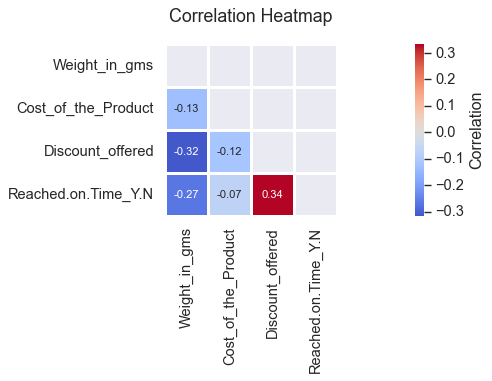

In [82]:
plt.figure(figsize=(20, 5))
sns.set_theme(style="dark", font_scale=1.2)
sns.heatmap(data=co,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=1,
            cbar_kws={'label': 'Correlation'},
            annot_kws={'size': 10},
            mask=np.triu(np.ones_like(co, dtype=bool)))
plt.title('Correlation Heatmap', pad=20, fontsize=16)
plt.tight_layout()

* **Weight vs Cost:** Weak negative correlation, -0.13.

* **Weight vs Discount:** Moderate negative correlation, -0.32.
* **Weight vs Delivery Time:** Moderate negative correlation, -0.27.
* **Cost vs Discount:** Weak negative correlation, -0.12.
* **Cost vs Delivery Time:** Very weak negative correlation, -0.07.
* **Discount vs Delivery Time:** Moderate positive correlation, 0.34.
* **Weight correlates most with delivery time and discount.**
* **Discount positively impacts on-time delivery likelihood.**

**On-Time delivery rate by Products Importance:**

In [83]:
data.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


In [84]:
data["Product_importance"].unique()

array(['low', 'medium', 'high'], dtype=object)

In [85]:
c= data.groupby(by= "Product_importance")["Reached.on.Time_Y.N"].value_counts(normalize= True).reset_index()
c

,Product_importance,Reached.on.Time_Y.N,proportion
0,high,1,0.649789
1,high,0,0.350211
2,low,1,0.592788
3,low,0,0.407212
4,medium,1,0.590450
5,medium,0,0.409550


In [86]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

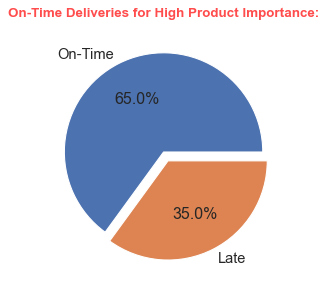

In [87]:
plt.figure(figsize=(4, 4))
plt.style.use("seaborn-v0_8-dark")
plt.pie(x= c[c["Product_importance"]== "high"]["proportion"], explode= [0, 0.1], autopct= "%1.1f%%", labels= ["On-Time", "Late"])
plt.title("On-Time Deliveries for High Product Importance:", fontsize=12, fontweight="bold", color="Red", pad=10, alpha=0.7)
plt.show()

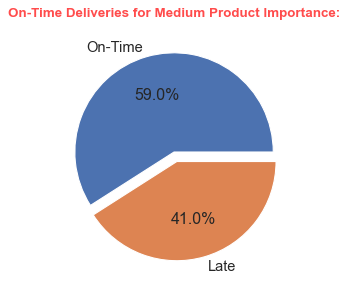

In [88]:
plt.figure(figsize=(4, 4))
plt.style.use("seaborn-v0_8-dark")
plt.pie(x= c[c["Product_importance"]== "medium"]["proportion"], explode= [0, 0.1], autopct= "%1.1f%%",labels= ["On-Time", "Late"] )
plt.title("On-Time Deliveries for Medium Product Importance:", fontsize=12, fontweight="bold", color="Red", pad=10, alpha=0.7)
plt.show()

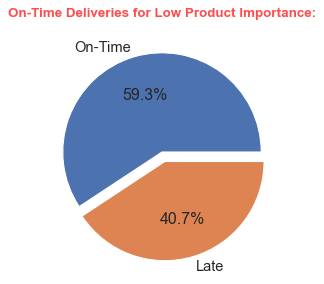

In [89]:
plt.figure(figsize=(4, 4))
plt.style.use("seaborn-v0_8-dark")
plt.pie(x= c[c["Product_importance"]== "low"]["proportion"], explode= [0, 0.1], autopct= "%1.1f%%",labels= ["On-Time", "Late"] )
plt.title("On-Time Deliveries for Low Product Importance:", fontsize=12, fontweight="bold", color="Red", pad=10, alpha=0.7)
plt.show()

From these pi-charts, we see that the importance of products can have influence on `on-time` deliveries. But to confirm this, lets perform statistical hypothesis test.

**`Hypothesis Testing`: Product Importance and Delivery of the Product:**

We want to test if the importance of the products being shipped can have influence on the  delicery timing (`on-time` or `late-delivery`). For this we will use Chi-Squared Test of Independence:

In [90]:
c

,Product_importance,Reached.on.Time_Y.N,proportion
0,high,1,0.649789
1,high,0,0.350211
2,low,1,0.592788
3,low,0,0.407212
4,medium,1,0.590450
5,medium,0,0.409550


In [91]:
data["Product_importance"].value_counts().reset_index()

,Product_importance,count
0,low,5297
1,medium,4754
2,high,948


In [92]:
from scipy.stats import chi2_contingency

n_total = 10999

# Approximate category counts (total = 10999)
importance_counts = {
    'high': 948,
    'low': 5297,
    'medium': 4754
}

# Given delivery proportions
delivery_props = {
    'high': [0.649789, 0.350211],
    'low': [0.592788, 0.407212],
    'medium': [0.590450, 0.409550]
}

# Create contingency table
contingency = []
for level in ['high', 'low', 'medium']:
    total = importance_counts[level]
    on_time = int(delivery_props[level][0] * total)
    late = total - on_time
    contingency.append([on_time, late])

# Chi-squared test
chi2_stat, p_value, dof, expected = chi2_contingency(contingency)

{
    "chi2_statistic": chi2_stat,
    "p_value": p_value,
    "degrees_of_freedom": dof,
    "conclusion": "Significant association" if p_value < 0.05 else "No significant association"
}

{'chi2_statistic': np.float64(11.854214920426191),
 'p_value': np.float64(0.002666182885908034),
 'degrees_of_freedom': 2,
 'conclusion': 'Significant association'}

There is a statistically significant association between `product importance` and `delivery time` $(p < 0.05)$. So, `product importance` does influence `delivery` performance.

-----
-----
-----
-----
-----
----

## **6. Customer Behavior Pattern Analysis:**

**What we do**: Investigate how customer characteristics and behavior patterns relate to delivery outcomes.

**Implementation approach**: Analyze delivery performance by gender, prior purchase history, and customer care calls frequency. Use cross-tabulation and chi-square tests to identify significant relationships, create segmented analysis visualizations.

In [93]:
data.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [94]:
# columns relating to customers behavior and characterstics:
cus_car= data[["Customer_care_calls", "Customer_rating", "Prior_purchases", "Discount_offered", "Gender", "Reached.on.Time_Y.N"]]
cus_car.head(3)

,Customer_care_calls,Customer_rating,Prior_purchases,Discount_offered,Gender,Reached.on.Time_Y.N
0,4,2,3,44,F,1
1,4,5,2,59,M,1
2,2,2,4,48,M,1


**Correlation of customer behavior characterstics and the delivery timing:**

In [95]:
coro= cus_car.select_dtypes(include=['int64', 'float64']).corr(method= "spearman")
coro

,Customer_care_calls,Customer_rating,Prior_purchases,Discount_offered,Reached.on.Time_Y.N
Customer_care_calls,1.000000,0.011862,0.272992,-0.104223,-0.064283
Customer_rating,0.011862,1.000000,0.010537,-0.002299,0.013108
Prior_purchases,0.272992,0.010537,1.000000,-0.093872,-0.074643
Discount_offered,-0.104223,-0.002299,-0.093872,1.000000,0.335108
Reached.on.Time_Y.N,-0.064283,0.013108,-0.074643,0.335108,1.000000


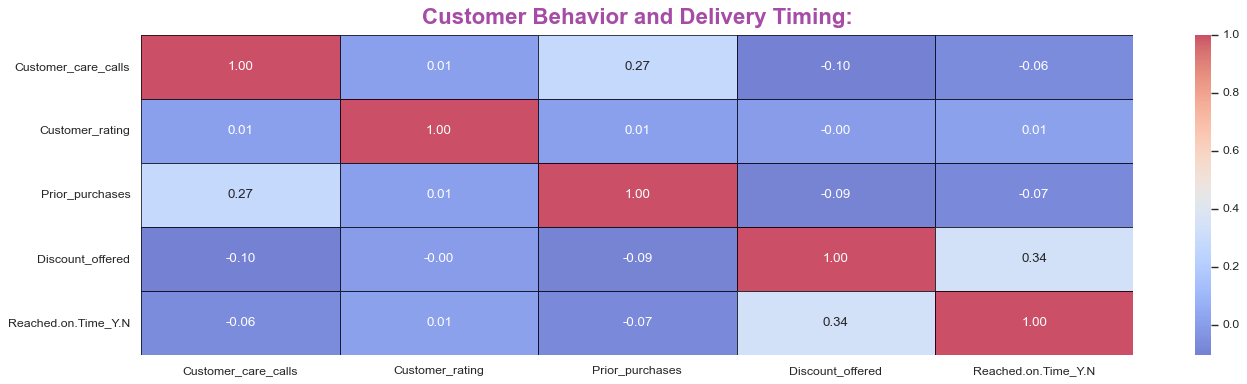

In [96]:
plt.figure(figsize= (20, 5))
sns.set_theme(context="notebook", style="white")
sns.heatmap(data= coro, annot= True, cmap= "coolwarm", fmt= ".2f", linewidths= 0.5, linecolor= "black", alpha= 0.7, square= False)
plt.title("Customer Behavior and Delivery Timing:", fontsize=20, fontweight="bold", color="Purple", pad=10, alpha=0.7)
plt.show()

* Customer care calls weakly correlated with prior purchases (0.27).

* More care calls slightly reduce delivery timeliness (-0.06).

* Customer rating has almost no correlations with others.

* Discount offered moderately increases late deliveries (0.33).

* Discount negatively linked with prior purchases (-0.09).

* Care calls slightly decrease with more discount (-0.10).

* Customer rating is almost independent from other variables.

* Discount has negligible link with rating (-0.002).

* Overall, most correlations are weak or negligible.

> **Questions:**
> 
> 1. Why customer ratings do not correlate with other parameters? This should correlate with other factors like `customer_care_calls`, `on-timr-delivery`, `prior-purchas` etc.
> 
> 2. Why `discounted products` seem to have `late-deleveries`.  
> 
> 3. Discount should generally increase the rating but this is not see, why?

**Delivery Performance by Gender:**

In [97]:
data.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [98]:
per_gen= data.groupby(by= "Gender")["Reached.on.Time_Y.N"].value_counts(normalize= True).reset_index(name= "count")
per_gen

,Gender,Reached.on.Time_Y.N,count
0,F,1,0.594409
1,F,0,0.405591
2,M,1,0.599010
3,M,0,0.400990


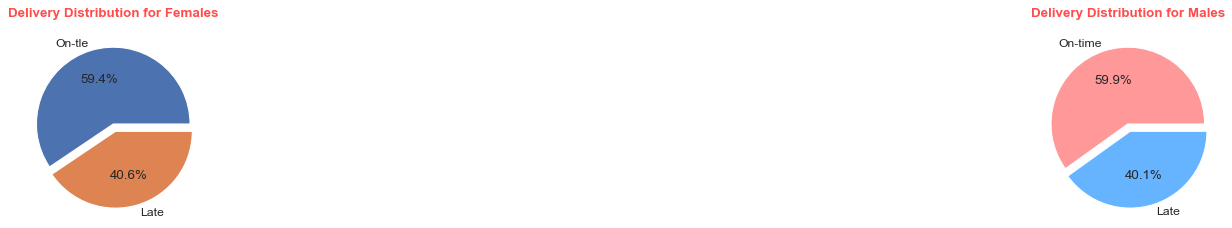

In [99]:
fig, ax= plt.subplots(1, 2, figsize=(30, 3))
ax= ax.flatten()
ax[0].pie(x= per_gen[per_gen["Gender"]== 'F']["count"], labels= ["On-tle", "Late"], explode= [0, 0.1], autopct= "%1.1f%%")
ax[0].set_title("Delivery Distribution for Females", fontsize= 12, fontweight="bold", color="Red", pad=10, alpha=0.7)
ax[1].pie(x= per_gen[per_gen["Gender"]== 'M']["count"], labels= ["On-time", "Late"], explode= [0, 0.1], colors= ["#ff9999", "#66b3ff"], autopct= "%1.1f%%" )
ax[1].set_title("Delivery Distribution for Males", fontsize= 12, fontweight="bold", color="Red", pad=10, alpha=0.7)
plt.show()

There is no significant difference in the delivery performance whether the order was by males or by females. 

**Delivery Performance by Prior Purchase History:**

> In general, the performance should be independent to the history of puchases. 

In [100]:
data.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [101]:
data["Prior_purchases"].unique()

array([ 3,  2,  4,  6,  5,  7, 10,  8])

Even though the variable is numeric, we can treat it categorical as very limited values also suggests categorical properties.

In [102]:
pp_rot= data.groupby(by= "Prior_purchases")["Reached.on.Time_Y.N"].value_counts(normalize=True).reset_index()
pp_rot

,Prior_purchases,Reached.on.Time_Y.N,proportion
0,2,1,0.625240
1,2,0,0.374760
2,3,1,0.640708
3,3,0,0.359292
4,4,1,0.543387
5,4,0,0.456613
6,5,0,0.501166
7,5,1,0.498834
8,6,1,0.559715
9,6,0,0.440285


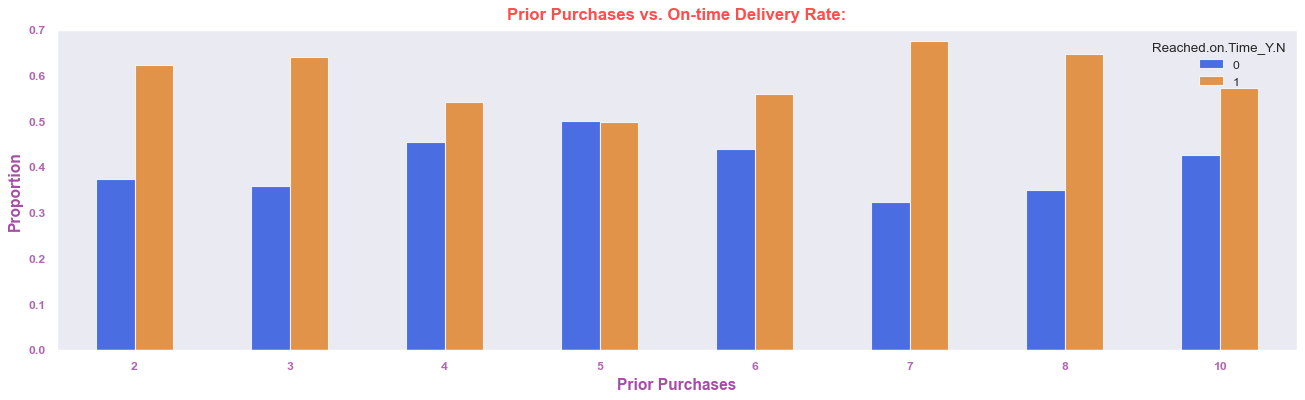

In [103]:
plt.figure(figsize=(20, 5))
sns.set_theme(context="notebook", style="dark")
sns.barplot(data= pp_rot, x= "Prior_purchases", y= "proportion", hue= "Reached.on.Time_Y.N", palette='bright', width=0.5, alpha= 0.8)
plt.title("Prior Purchases vs. On-time Delivery Rate:", fontsize=15, fontweight="bold", color="Red", pad=10, alpha=0.7)
plt.xlabel("Prior Purchases", color="purple", fontweight="bold", alpha=0.7, fontsize= 14)
plt.ylabel("Proportion", color="purple", fontweight="bold", alpha=0.7, fontsize= 14)
plt.xticks(color= "purple", fontweight="bold", alpha=0.6, fontsize= 11)
plt.yticks(color= "purple", fontweight="bold", alpha=0.6, fontsize= 11)
plt.show()

There is no strong or clear evidence to suggest that on-time delivery depends directly on the number of prior purchases. While some values of prior purchases (like 7 and 8) show higher on-time delivery rates but similar relation is also seen for (prior purchase= 2 and 3), the pattern is not linear or consistent enough to establish dependency.

On-time delivery does not strongly depend on the number of prior purchases. Other factors are likely influencing delivery performance.

**Delivery Performance by Customer Care Calls Frequency:**

In [104]:
data.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [105]:
ccc_rr= data.groupby(by= "Customer_care_calls")["Reached.on.Time_Y.N"].value_counts(normalize= True).reset_index()
ccc_rr

,Customer_care_calls,Reached.on.Time_Y.N,proportion
0,2,1,0.652038
1,2,0,0.347962
2,3,1,0.625117
3,3,0,0.374883
4,4,1,0.597695
5,4,0,0.402305
6,5,1,0.584192
7,5,0,0.415808
8,6,1,0.516288
9,6,0,0.483712


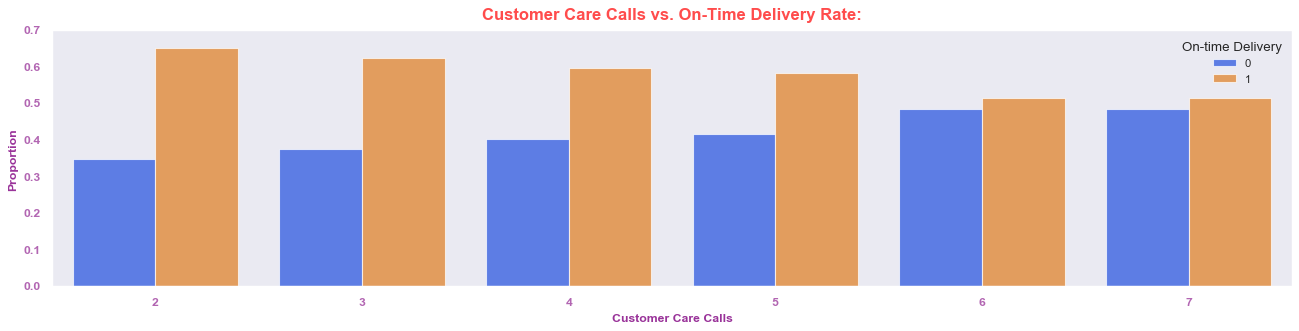

In [106]:
plt.figure(figsize=(20, 4))
sns.set_theme(context="notebook", style="dark")
sns.barplot(data= ccc_rr, x= "Customer_care_calls", y= "proportion", palette="bright", alpha= 0.7, hue= "Reached.on.Time_Y.N")
plt.title("Customer Care Calls vs. On-Time Delivery Rate:", fontsize=15, fontweight="bold", color="Red", pad=10, alpha=0.7)
plt.xlabel("Customer Care Calls", color="purple", fontweight="bold", alpha=0.8, fontsize= 11)
plt.ylabel("Proportion", color="purple", fontweight="bold", alpha=0.8, fontsize= 11)
plt.xticks(color= "purple", fontweight="bold", alpha=0.6, fontsize= 11)
plt.yticks(color= "purple", fontweight="bold", alpha=0.6, fontsize= 11)
plt.legend(title= "On-time Delivery", loc= "upper right", fontsize= 10)
plt.show()

There appears to be a weak inverse relationship between the number of customer care calls and on-time delivery:

- As the number of customer calls increases, on-time delivery rate tends to decrease.

- This could indicate that more calls to customer care may be associated with delivery issues, possibly due to delays or customer dissatisfaction.

**Hypothesis Testing to Confirm this Relationship:**

* **Null Hypothesis $(H₀)$:**
  There is **no association** between the number of customer care calls and on-time delivery status.

* **Alternative Hypothesis $(H₁)$:**
  There **is an association** between the number of customer care calls and on-time delivery status. 

In [107]:
import scipy.stats as stats

# Create a contingency table
contingency_table = pd.crosstab(data['Customer_care_calls'], data['Reached.on.Time_Y.N'])
contingency_table

Reached.on.Time_Y.N,0,1
Customer_care_calls,,
2,222,416
3,1206,2011
4,1431,2126
5,968,1360
6,490,523
7,119,127


In [108]:
# Perform the Chi-Square Test of Independence
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

# Print the results
print("Chi-square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("P-value:", p)
print("Alpha", alpha)

# Decision
alpha = 0.05
if p < alpha:
    print("Reject the null hypothesis. There is a significant association between customer care calls and on-time delivery.")
else:
    print("Fail to reject the null hypothesis. No significant association found.")

Chi-square Statistic: 54.27373399881683
Degrees of Freedom: 5
P-value: 1.8411500205173969e-10
Alpha 0.05
Reject the null hypothesis. There is a significant association between customer care calls and on-time delivery.


> **Decision Rule:**
> 
> * If **p < 0.05**, you **reject H₀** and conclude that **customer care calls and on-time delivery are dependent**.
> * If **p ≥ 0.05**, you **fail to reject H₀**, meaning there is **no significant evidence** of dependency.

So, we conclude that, the evidences are to reject Null Hypothesis. Customer Care Calls is associated with On-time delivery of the products. 

----
----
----
---
---
---
---
----
---

## **7. Customer Service Call Impact Assessment:**

In [109]:
data.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [110]:
vals= data[["Customer_care_calls", "Reached.on.Time_Y.N"]]
vals.head(3)

,Customer_care_calls,Reached.on.Time_Y.N
0,4,1
1,4,1
2,2,1


**1. Correlation Analysis:**   

The correlation coefficient (Spearman, is non-parametric and based on ranks) will tell if there is a monotonic relationship between the number of calls and the likelihood of on-time delivery.

**`Negative correlation`**: More calls are associated with late deliveries (i.e., as calls increase, the probability of on-time delivery decreases).

**`Positive correlation`**: More calls are associated with on-time deliveries.

**`Near zero`**: No relationship.

In [111]:
correlation = data[['Customer_care_calls', 'Reached.on.Time_Y.N']].corr(method='spearman')
print("Spearman Correlation:\n", correlation)

Spearman Correlation:
                      Customer_care_calls  Reached.on.Time_Y.N
Customer_care_calls             1.000000            -0.064283
Reached.on.Time_Y.N            -0.064283             1.000000


Spearman correlation between `Customer_care_calls` and `Reached.on.Time_Y.N` shows a very weak negative monotonic correlation. As the number of customer care calls increases, the likelihood of `on-time delivery` very slightly decreases, but the relationship is `extremely weak`.

**2. Call Frequency Distribution:**

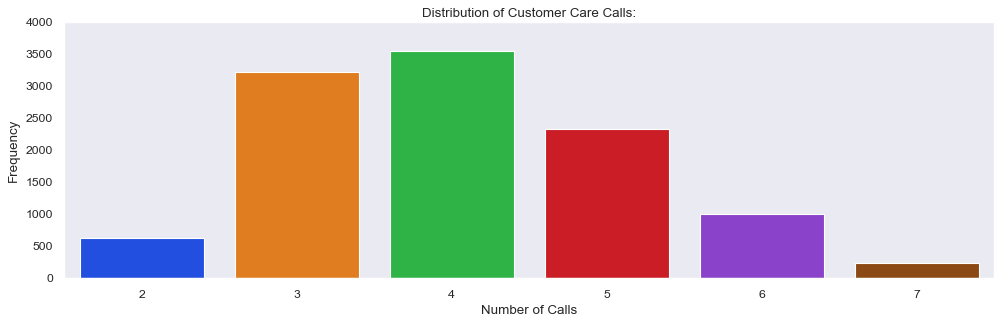

In [112]:
plt.figure(figsize=(15,4))
sns.countplot(x='Customer_care_calls', data=data, palette='bright')
plt.title("Distribution of Customer Care Calls:")
plt.xlabel("Number of Calls")
plt.ylabel("Frequency")
plt.show()

• Peak frequency occurs at 4 calls per customer

• Second highest frequency is 3 calls per customer

• 5 calls per customer shows moderate frequency

• Very few customers make only 2 calls

• 6 calls per customer has low frequency

• 7 calls per customer shows minimal occurrence

• Distribution skews right with declining tail frequencies

**3. Scatter Plot & Regression:**  
Visualize the relationship and fit a regression line:

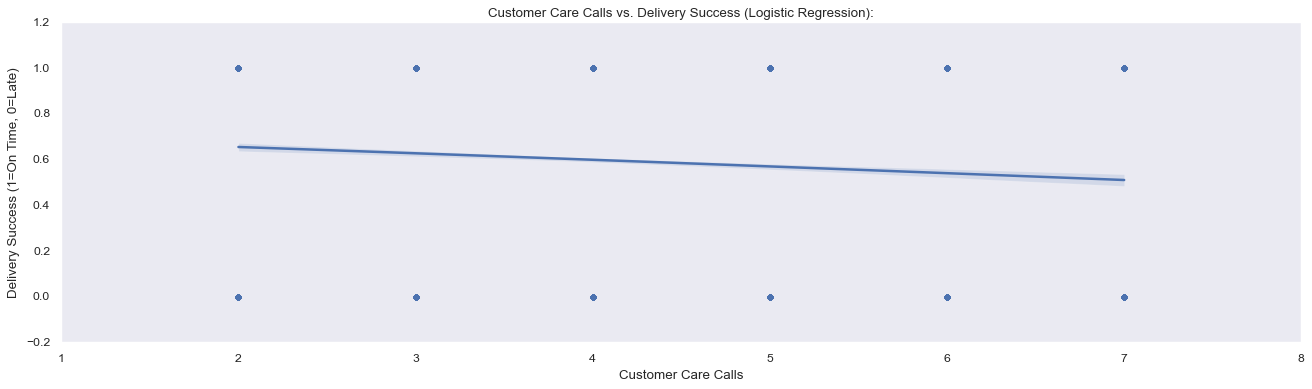

In [113]:
plt.figure(figsize=(20,5))
sns.regplot(
    x='Customer_care_calls',
    y='Reached.on.Time_Y.N',
    data=data,
    logistic=True,  # Use logistic regression for binary outcome
    scatter_kws={'alpha':0.3}
)
plt.title("Customer Care Calls vs. Delivery Success (Logistic Regression):")
plt.xlabel("Customer Care Calls")
plt.ylabel("Delivery Success (1=On Time, 0=Late)")
plt.show()

4. **Logistic Regression for Deeper Insight**
Check if more calls predict late delivery:

In [114]:
import statsmodels.api as sm

X = data[['Customer_care_calls']]
X = sm.add_constant(X)
y = data['Reached.on.Time_Y.N']

model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.672081
         Iterations 4
                            Logit Regression Results                           
Dep. Variable:     Reached.on.Time_Y.N   No. Observations:                10999
Model:                           Logit   Df Residuals:                    10997
Method:                            MLE   Df Model:                            1
Date:                 Thu, 12 Jun 2025   Pseudo R-squ.:                0.003336
Time:                         11:29:29   Log-Likelihood:                -7392.2
converged:                        True   LL-Null:                       -7417.0
Covariance Type:             nonrobust   LLR p-value:                 1.993e-12
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.8789      0.072     12.163      0.000       0.737       

• Very low pseudo R-squared (0.003) indicates `poor model fit`

• Customer care calls significantly reduce on-time delivery probability

• Each additional call decreases odds by approximately 11.3%

• Constant term is 0.88, baseline positive delivery probability

• P-values show statistically significant results (p < 0.001)

• Confidence intervals don't include zero, confirming significance

• Model explains only 0.33% of variance in outcomes

• Strong evidence that more calls predict delivery delays

> Each additional customer care call reduces odds of on-time delivery by about 11.3%. Model has very weak predictive power despite statistical significance. `Customer care calls` are definitely related to `delivery delays`, but study should include additional factors. 

----
----
----
----
----
---
---
---
---
----
----

## **8. Customer Rating vs Delivery Performance Correlation:**

In [115]:
data.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

**1. Correlation Analysis between `Customer_rating` and `Reached.on.Time_Y.N`:**

In [116]:
data[["Reached.on.Time_Y.N", "Customer_rating"]].corr(method= "spearman")

,Reached.on.Time_Y.N,Customer_rating
Reached.on.Time_Y.N,1.000000,0.013108
Customer_rating,0.013108,1.000000


The correlation coefficient between `Reached.on.Time_Y.N` and `Customer_rating` is 0.013108. This value is very close to zero, suggesting that there is almost no monotonic relationship between these two variables making all other variables constant. Again, this is contradicting to general understanding; these variables should be positively correlated (moderate if not high positive correlation). 

**2. Rating Distribution for on-time and Delays:**

In [117]:
# Data for on time deliveries:
data1= data[data["Reached.on.Time_Y.N"]== 1]
data1.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


In [118]:
# Data for on late deliveries:
data2= data[data["Reached.on.Time_Y.N"]== 0]
data.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


<Axes: xlabel='Customer_rating'>

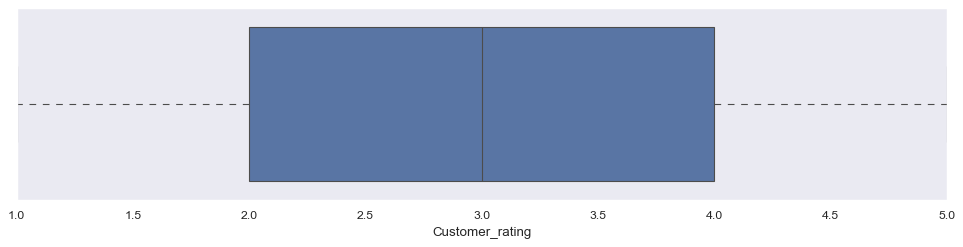

In [119]:
# Distribution plot for ontime deliveries: 
plt.figure(figsize=(15, 3))
sns.set_theme(context="notebook", style="dark") 
sns.boxplot(data= data1, x= "Customer_rating")

<Axes: xlabel='Customer_rating'>

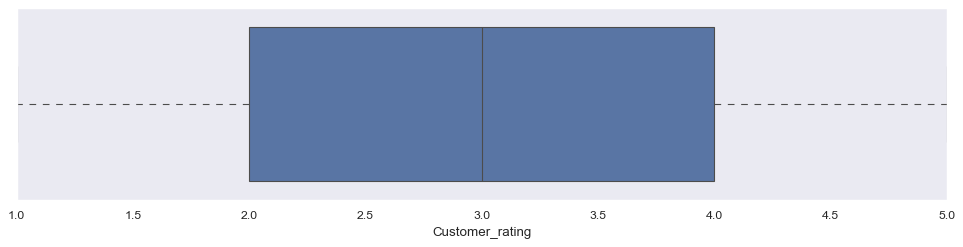

In [120]:
# Distribution plot for delayed deliveries: 
plt.figure(figsize=(15, 3))
sns.set_theme(context="notebook", style="dark") 
sns.boxplot(data= data2, x= "Customer_rating")

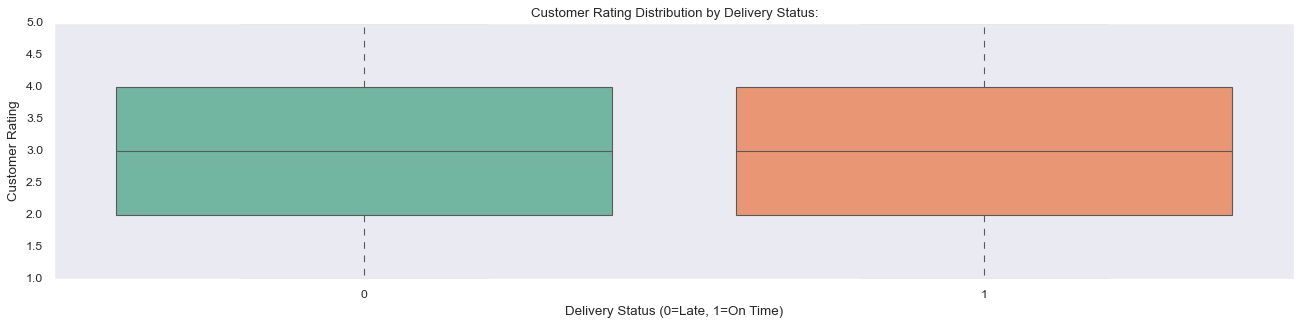

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 4))
sns.boxplot(x='Reached.on.Time_Y.N', y='Customer_rating', data=data, palette='Set2')
plt.title('Customer Rating Distribution by Delivery Status:')
plt.xlabel('Delivery Status (0=Late, 1=On Time)')
plt.ylabel('Customer Rating')
plt.show()

The distributions are exact photocopy of each other. There should be significant difference between these distributions but the dataset says something different.

**3. Statistical Test:**  
We use a `Mann-Whitney U test` to check if the distributions are significantly different.

The `Mann-Whitney U test` is a non-parametric statistical test used to determine whether there is a significant difference between the distributions of two independent groups. It does not assume normality of the data and is often used as an alternative to the independent samples t-test when the data are ordinal or not normally distributed.

It tests whether the distribution of customer ratings is different for on-time deliveries versus late deliveries. If the `p-value` is less than 0.05, it suggests a significant difference between the two groups; otherwise, there is no significant difference.

In [122]:
from scipy.stats import mannwhitneyu

on_time = data[data['Reached.on.Time_Y.N'] == 1]['Customer_rating']
late = data[data['Reached.on.Time_Y.N'] == 0]['Customer_rating']

In [123]:
stat, p = mannwhitneyu(on_time, late, alternative='two-sided')
print(f"Mann-Whitney U test statistic: {stat:.4f}, p-value: {p:.4f}")

if p < 0.05:
    print("Significant difference in customer ratings between on-time and late deliveries.")
else:
    print("No significant difference in customer ratings between on-time and late deliveries.")

Mann-Whitney U test statistic: 14776762.0000, p-value: 0.1692
No significant difference in customer ratings between on-time and late deliveries.


There is no significant evidence to reject Null Hypothesis. So, statistical testing also confirms that the distributions of customers ratings are identical. 

----
----
----
---
----
---
---
---
---

## **9. Multi-factor Impact Analysis:**

> Identify which combination of factors most significantly impact delivery performance. 

In [124]:
data.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

**1. Correlation Analysis:**

In [125]:
data.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


In [126]:
data.select_dtypes(include=['int64', 'float64']).columns

Index(['ID', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
       'Prior_purchases', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [127]:
corona= data[['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
       'Prior_purchases', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N']].corr(method= "spearman")
corona

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
Customer_care_calls,1.000000,0.011862,0.293700,0.272992,-0.104223,-0.232936,-0.064283
Customer_rating,0.011862,1.000000,0.010242,0.010537,-0.002299,-0.004803,0.013108
Cost_of_the_Product,0.293700,0.010242,1.000000,0.194216,-0.115817,-0.131980,-0.071850
Prior_purchases,0.272992,0.010537,0.194216,1.000000,-0.093872,-0.234673,-0.074643
Discount_offered,-0.104223,-0.002299,-0.115817,-0.093872,1.000000,-0.315677,0.335108
Weight_in_gms,-0.232936,-0.004803,-0.131980,-0.234673,-0.315677,1.000000,-0.265958
Reached.on.Time_Y.N,-0.064283,0.013108,-0.071850,-0.074643,0.335108,-0.265958,1.000000


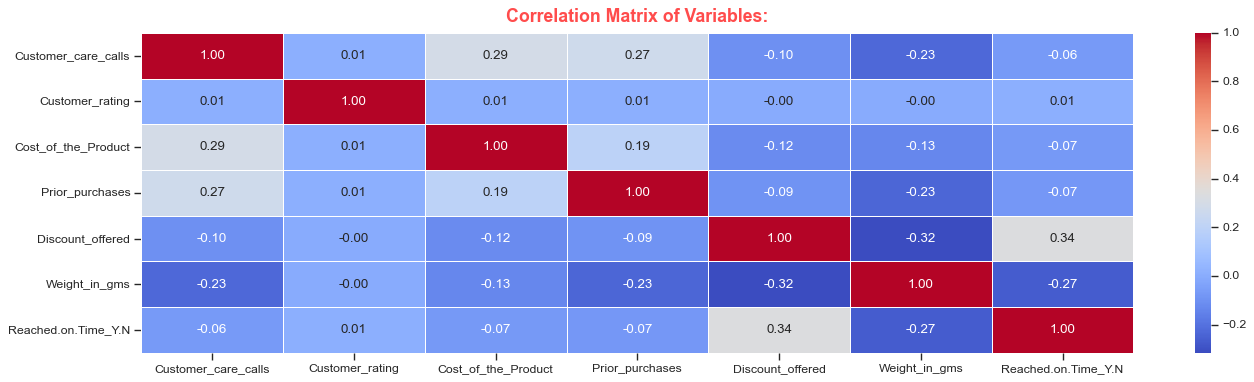

In [128]:
plt.figure(figsize=(20, 5))
plt.style.use("dark_background")
sns.set_theme(context="notebook", style="ticks")
sns.heatmap(corona, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, robust= True, square= False)
plt.title("Correlation Matrix of Variables:", fontsize=16, fontweight="bold", color="Red", pad=10, alpha=0.7)
plt.show()

Neither of the variables in the dataaset shows high correlation and most of the correlation coefficient values are around zero. 

* **Customer care calls** weakly correlates with **product cost** (0.29).

* **Customer rating** has no strong correlation with other variables.
* **Cost of product** positively correlates with **customer care calls** (0.29).
* **Prior purchases** mildly correlate with **customer care calls** (0.27).
* **Discount offered** negatively correlates with **weight** (-0.32).
* **Reached on time** positively correlates with **discount offered** (0.34).
* **Weight in gms** negatively correlates with **reached on time** (-0.27).
* **Customer care calls** slightly negatively correlate with **weight** (-0.23).
* **All other correlations** are weak or near zero.

**2. Feature Importance with Tree-Based Models:**

Feature importance measures how much each input variable contributes to the model's predictions. 
It helps identify which factors have the strongest influence on delivery performance

**Tree-based models like Random Forests (`RandomForestClassifier`) are great for feature importance because:**  
  1. They naturally handle both numeric and categorical features

  2. They can capture non-linear relationships between features
  3. They provide built-in feature importance scores based on how often features are used to split data
  4. The importance scores are easy to interpret - higher values = more important features
  5. They're less sensitive to outliers compared to linear models

In [129]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

# One-hot encode categorical variables and separate features (X) and target (y)
X = pd.get_dummies(data.drop(['Reached.on.Time_Y.N', "ID"], axis=1), drop_first=True)
y = data['Reached.on.Time_Y.N']

# Using a train-test split to assess permutation importance reliably
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the Random Forest Classifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

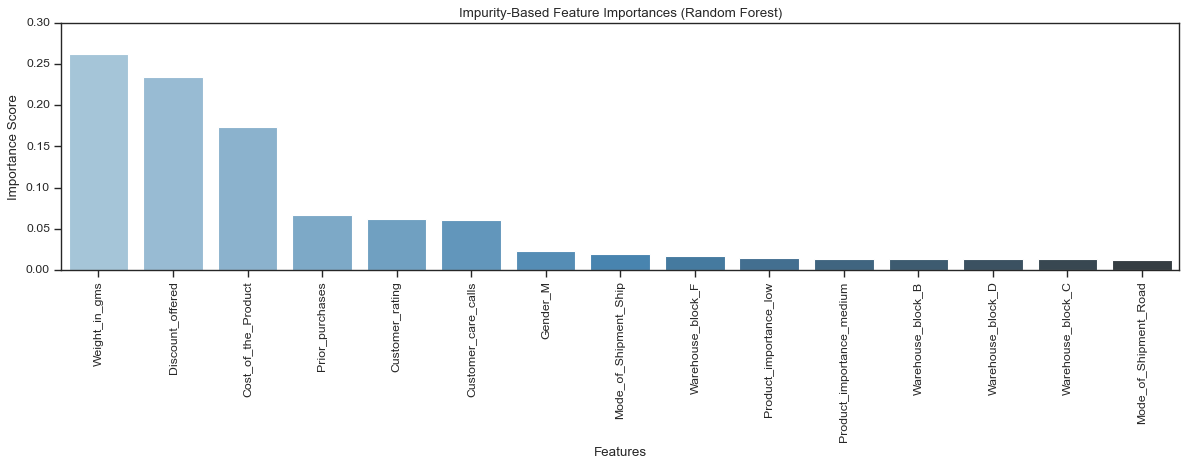

In [130]:
# Plot impurity-based feature importances
# These are based on how much each feature reduces Gini impurity across the trees
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(15, 6))
#importances.plot(kind='bar')
sns.barplot(x=importances.index, y=importances.values, palette="Blues_d")

plt.title("Impurity-Based Feature Importances (Random Forest)")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

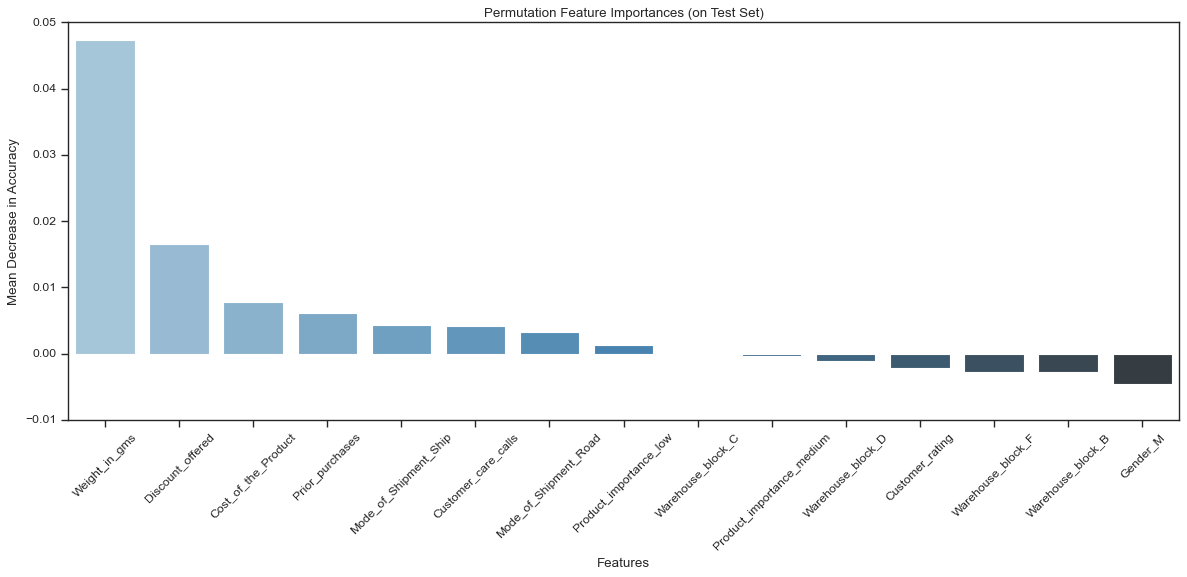

In [131]:
# Compute permutation feature importances: 
# This assesses how shuffling each feature affects model performance
perm_results = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42, scoring='accuracy')
perm_importances = pd.Series(perm_results.importances_mean, index=X.columns).sort_values(ascending=False)

# Plot permutation importances:
plt.figure(figsize=(15, 6))
#perm_importances.plot(kind='bar', color='orange')
sns.barplot(x=perm_importances.index, y=perm_importances.values, palette="Blues_d")
plt.title("Permutation Feature Importances (on Test Set)")
plt.xlabel("Features")
plt.ylabel("Mean Decrease in Accuracy")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

- `Weight_in_gms` is the most influential feature for delivery prediction.

- `Discount_offered` also plays a key role in model decisions.

- `Cost_of_the_Product` has moderate importance in the model.

- `Prior_purchases` and `Customer_rating` have mild predictive power.

- `Customer_care_calls` contributes slightly to predictions.

- `Gender_M` and `Mode_of_Shipment_Ship` have low importance.

- `Warehouse_block_*` features show very little contribution.

- `Product_importance_low/medium` are not very informative.

- `Mode_of_Shipment_Road` is the least impactful among all.

**3. Chi-Square Tests for Categorical Variables:**

In [132]:
data.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [133]:
data.head(2)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1


In [134]:
cat_cols= data[["Warehouse_block", "Mode_of_Shipment", "Customer_care_calls", 'Customer_rating', 'Prior_purchases', 'Product_importance', 'Gender', 'Reached.on.Time_Y.N']]
cat_cols.head(3)

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Prior_purchases,Product_importance,Gender,Reached.on.Time_Y.N
0,D,Flight,4,2,3,low,F,1
1,F,Flight,4,5,2,low,M,1
2,A,Flight,2,2,4,low,M,1


In [135]:
cat_cols.columns

Index(['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Prior_purchases', 'Product_importance', 'Gender',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [136]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(cat_cols["Warehouse_block"], cat_cols["Reached.on.Time_Y.N"])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"p-value: {p}")

p-value: 0.8959524278243698


> There seems to have no significant differences on `on-time delivery` for difference `warehouse blocks`. 

> **Interpretation Guide:**
> 
> `p < 0.05`: Significant difference exists   
> `p ≥ 0.05`: No significant difference

In [137]:
contingency = pd.crosstab(data['Mode_of_Shipment'], data['Reached.on.Time_Y.N'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"p-value: {p}")

p-value: 0.6895487627593786


> There seems to have no significant differences on `on-time delivery` for different `mode of shipments`.

In [138]:
contingency = pd.crosstab(data['Customer_care_calls'], data['Reached.on.Time_Y.N'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"p-value: {p:.10f}")

p-value: 0.0000000002


> There seems to have a significant differences on `on-time delivery` for different `warehouse blocks`.

In [139]:
contingency = pd.crosstab(data['Customer_rating'], data['Reached.on.Time_Y.N'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"p-value: {p}")

p-value: 0.5249236018493662


> There seems to have no significant differences on `on-time delivery` based on `customers ratings`.

In [140]:
contingency = pd.crosstab(data['Prior_purchases'], data['Reached.on.Time_Y.N'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"p-value: {p:.10f}")

p-value: 0.0000000000


> There seems to have a significant differences in `on-time delivery` based on `customer prior purchases`.

In [141]:
contingency = pd.crosstab(data['Product_importance'], data['Reached.on.Time_Y.N'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"p-value: {p}")

p-value: 0.002230383104745087


> As `p-value < 0.05`: there is a statistically significant association between `product_importance` and `Reached.on.Time_Y.N`.
> This means the proportion of `product_importance` vs. `late deliveries` is different across importance categories.

In [142]:
contingency = pd.crosstab(data['Gender'], data['Reached.on.Time_Y.N'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"p-value: {p}")

p-value: 0.6367032124181522


> As `p-value > 0.05`: there is no statistically significant association between `Gender` and `Reached.on.Time_Y.N`.

In [143]:
contingency = pd.crosstab(data['Reached.on.Time_Y.N'], data['Reached.on.Time_Y.N'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"p-value: {p:.10f}")

p-value: 0.0000000000


> As `p-value < 0.05`: there is a statistically significant association between `Reached.on.Time_Y.N` and `Reached.on.Time_Y.N` ie. with itself. 

**4. ANOVA for Continuous Variables:**    

Test if means of continuous variables (e.g., `product cost`, `weight`) differ significantly between `on-time` and `late deliveries`. We use `scipy.stats.ttest_ind` for two groups.

In [144]:
data.select_dtypes(include= ["int32", "int64"]).columns

Index(['ID', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
       'Prior_purchases', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [145]:
from scipy.stats import ttest_ind

on_time = data[data['Reached.on.Time_Y.N'] == 1]['Cost_of_the_Product']
late = data[data['Reached.on.Time_Y.N'] == 0]['Cost_of_the_Product']
stat, p = ttest_ind(on_time, late)
print(f"p-value: {p:.20f}")
print("-"*100)
# Decision criterion and statistical decision
alpha = 0.05
print(f"Decision criterion: If p-value < {alpha}, reject the null hypothesis \n(significant difference in mean product cost between on-time and late deliveries).")
print("-"*100)
if p < alpha:
    print("Statistical decision: Reject the null hypothesis. There is a \nstatistically significant difference in the mean cost of the \nproduct between on-time and late deliveries.")
else:
    print("Statistical decision: Fail to reject the null hypothesis. \n There is no statistically significant difference in the mean \n cost of the product between \n on-time and late deliveries.")

p-value: 0.00000000000001099886
----------------------------------------------------------------------------------------------------
Decision criterion: If p-value < 0.05, reject the null hypothesis 
(significant difference in mean product cost between on-time and late deliveries).
----------------------------------------------------------------------------------------------------
Statistical decision: Reject the null hypothesis. There is a 
statistically significant difference in the mean cost of the 
product between on-time and late deliveries.


In [146]:
on_time = data[data['Reached.on.Time_Y.N'] == 1]['Customer_care_calls']
late = data[data['Reached.on.Time_Y.N'] == 0]['Customer_care_calls']
stat, p = ttest_ind(on_time, late)
print(f"p-value: {p:.20f}")

print("-"*100)
# Decision criterion and statistical decision
alpha = 0.05
print(f"Decision criterion: If p-value < {alpha}, reject the null hypothesis \n(significant difference in mean product cost between on-time and late deliveries).")
print("-"*100)
if p < alpha:
    print("Statistical decision: Reject the null hypothesis. There is a \nstatistically significant difference in the mean number of customer-care calls \nbetween on-time and late deliveries.")
else:
    print("Statistical decision: Fail to reject the null hypothesis. \n There is no statistically significant difference in the mean \n cost of the product between \n on-time and late deliveries.")

p-value: 0.00000000000182753518
----------------------------------------------------------------------------------------------------
Decision criterion: If p-value < 0.05, reject the null hypothesis 
(significant difference in mean product cost between on-time and late deliveries).
----------------------------------------------------------------------------------------------------
Statistical decision: Reject the null hypothesis. There is a 
statistically significant difference in the mean number of customer-care calls 
between on-time and late deliveries.


In [147]:
on_time = data[data['Reached.on.Time_Y.N'] == 1]['Customer_rating']
late = data[data['Reached.on.Time_Y.N'] == 0]['Customer_rating']
stat, p = ttest_ind(on_time, late)
print(f"p-value: {p:.20f}")

print("-"*100)
# Decision criterion and statistical decision
alpha = 0.05
print(f"Decision criterion: If p-value < {alpha}, reject the null hypothesis \n(significant difference in mean customer rating between on-time and late deliveries).")
print("-"*100)
if p < alpha:
    print("Statistical decision: Reject the null hypothesis. There is a \nstatistically significant difference in the mean cost of the \nproduct between on-time and late deliveries.")
else:
    print("Statistical decision: Fail to reject the null hypothesis. \n There is no statistically significant difference in the mean \n cost of the product between on-time and late deliveries.")

p-value: 0.16890489722530824257
----------------------------------------------------------------------------------------------------
Decision criterion: If p-value < 0.05, reject the null hypothesis 
(significant difference in mean customer rating between on-time and late deliveries).
----------------------------------------------------------------------------------------------------
Statistical decision: Fail to reject the null hypothesis. 
 There is no statistically significant difference in the mean 
 cost of the product between on-time and late deliveries.


In [148]:
on_time = data[data['Reached.on.Time_Y.N'] == 1]['Prior_purchases']
late = data[data['Reached.on.Time_Y.N'] == 0]['Prior_purchases']
stat, p = ttest_ind(on_time, late)
print(f"p-value: {p:.20f}")

print("-"*100)
# Decision criterion and statistical decision
alpha = 0.05
print(f"Decision criterion: If p-value < {alpha}, reject the null hypothesis \n(significant difference in mean number of prior purchases and late deliveries).")
print("-"*100)
if p < alpha:
    print("Statistical decision: Reject the null hypothesis. There is a \nstatistically significant difference in the mean cost of the \nproduct between on-time and late deliveries.")
else:
    print("Statistical decision: Fail to reject the null hypothesis. \n There is no statistically significant difference in the mean \n cost of the product between \n on-time and late deliveries.")

p-value: 0.00000000567614048397
----------------------------------------------------------------------------------------------------
Decision criterion: If p-value < 0.05, reject the null hypothesis 
(significant difference in mean number of prior purchases and late deliveries).
----------------------------------------------------------------------------------------------------
Statistical decision: Reject the null hypothesis. There is a 
statistically significant difference in the mean cost of the 
product between on-time and late deliveries.


In [149]:
on_time = data[data['Reached.on.Time_Y.N'] == 1]['Discount_offered']
late = data[data['Reached.on.Time_Y.N'] == 0]['Discount_offered']
stat, p = ttest_ind(on_time, late)
print(f"p-value: {p:.10f}")

print("-"*100)
# Decision criterion and statistical decision
alpha = 0.05
print(f"Decision criterion: If p-value < {alpha}, reject the null hypothesis \n(significant difference in mean discount offered between on-time and late deliveries).")
print("-"*100)
if p < alpha:
    print("Statistical decision: Reject the null hypothesis. There is a \nstatistically significant difference in the mean cost of the \nproduct between on-time and late deliveries.")
else:
    print("Statistical decision: Fail to reject the null hypothesis. \n There is no statistically significant difference in the mean \n cost of the product between \n on-time and late deliveries.")

p-value: 0.0000000000
----------------------------------------------------------------------------------------------------
Decision criterion: If p-value < 0.05, reject the null hypothesis 
(significant difference in mean discount offered between on-time and late deliveries).
----------------------------------------------------------------------------------------------------
Statistical decision: Reject the null hypothesis. There is a 
statistically significant difference in the mean cost of the 
product between on-time and late deliveries.


In [150]:
on_time = data[data['Reached.on.Time_Y.N'] == 1]['Weight_in_gms']
late = data[data['Reached.on.Time_Y.N'] == 0]['Weight_in_gms']
stat, p = ttest_ind(on_time, late)
print(f"p-value: {p:.20f}")

print("-"*100)
# Decision criterion and statistical decision
alpha = 0.05
print(f"Decision criterion: If p-value < {alpha}, reject the null hypothesis \n(significant difference in mean weight between on-time and late deliveries).")
print("-"*100)
if p < alpha:
    print("Statistical decision: Reject the null hypothesis. There is a \nstatistically significant difference in the mean cost of the \nproduct between on-time and late deliveries.")
else:
    print("Statistical decision: Fail to reject the null hypothesis. \n There is no statistically significant difference in the mean \n cost of the product between \n on-time and late deliveries.")

p-value: 0.00000000000000000000
----------------------------------------------------------------------------------------------------
Decision criterion: If p-value < 0.05, reject the null hypothesis 
(significant difference in mean weight between on-time and late deliveries).
----------------------------------------------------------------------------------------------------
Statistical decision: Reject the null hypothesis. There is a 
statistically significant difference in the mean cost of the 
product between on-time and late deliveries.


---
----
---
----
----
----

## **10. Geographic and Operational Pattern Discovery:**

In [151]:
data.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [152]:
mm= data[["Warehouse_block", "Mode_of_Shipment", "Reached.on.Time_Y.N"]]
mm.head(6)

,Warehouse_block,Mode_of_Shipment,Reached.on.Time_Y.N
0,D,Flight,1
1,F,Flight,1
2,A,Flight,1
3,B,Flight,1
4,C,Flight,1
5,F,Flight,1


**1. On-Time Delivery Comparision of Different Warehouse Blocks with Different Shiping Modes:**

In [153]:
data["Warehouse_block"].unique() # Not to confuse; no E-block in the dataset.

array(['D', 'F', 'A', 'B', 'C'], dtype=object)

In [154]:
ak= mm.groupby(by= ["Warehouse_block", "Mode_of_Shipment"])["Reached.on.Time_Y.N"].value_counts(normalize= True).reset_index(name= "count")
ak.head(7)

,Warehouse_block,Mode_of_Shipment,Reached.on.Time_Y.N,count
0,A,Flight,1,0.585859
1,A,Flight,0,0.414141
2,A,Road,1,0.571429
3,A,Road,0,0.428571
4,A,Ship,1,0.590177
5,A,Ship,0,0.409823
6,B,Flight,1,0.597973


In [155]:
enumerate(ak)
for i, v in enumerate(ak):
    (print(i, v))

0 Warehouse_block
1 Mode_of_Shipment
2 Reached.on.Time_Y.N
3 count


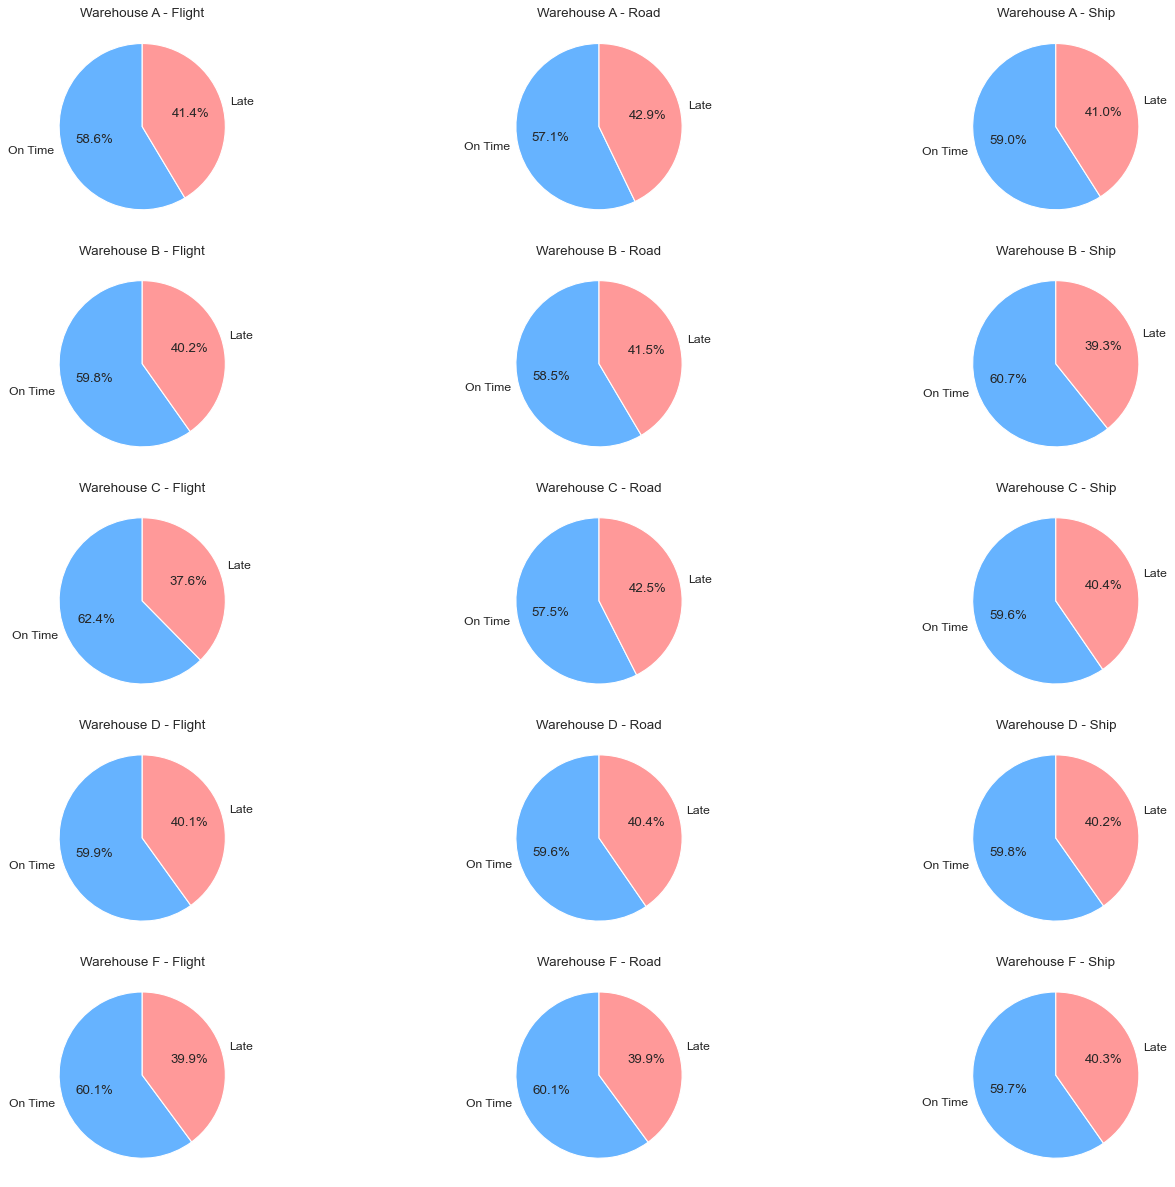

In [156]:
warehouse_blocks = ak['Warehouse_block'].unique()
modes = ak['Mode_of_Shipment'].unique()

# Create subplots: one row per warehouse, one column per shipment mode
fig, axes = plt.subplots(len(warehouse_blocks), len(modes), figsize=(19, 3 * len(warehouse_blocks)))
axes = axes.flatten()  # Flatten axes for easier iteration

sns.set_theme(context="notebook", style="darkgrid")

# Iterate using enumerate for both warehouse and mode
for i, warehouse in enumerate(warehouse_blocks):
    for j, mode in enumerate(modes):
        idx = i * len(modes) + j  # Calculate flat index
        # Filter data for current warehouse and mode
        subset = ak[(ak['Warehouse_block'] == warehouse) & (ak['Mode_of_Shipment'] == mode)]
        if not subset.empty:
            sizes = subset['count'].values
            labels = ['On Time' if x == 1 else 'Late' for x in subset['Reached.on.Time_Y.N']]
            axes[idx].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999'])
            axes[idx].set_title(f'Warehouse {warehouse} - {mode}')
        else:
            axes[idx].axis('off')  # Hide unused subplot

plt.tight_layout()
plt.show()

No significant differences have been observed between different warehouse deliveries through different shipping modes. All the warehouses shows almost similar patterns.

In [157]:
data.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

**2. Create a Pivot Table:**

A **`pivot table`** summarizes data by grouping it by one or more categorical variables and applying an aggregation function (like mean or count).  
Here, we want to see the **on-time delivery rate** for each combination of `Warehouse_block` and `Mode_of_Shipment`.

In [158]:
# Calculate mean on-time delivery rate for each warehouse and shipment mode
pivot = data.pivot_table(
    values='Reached.on.Time_Y.N', 
    index='Warehouse_block', 
    columns='Mode_of_Shipment', 
    aggfunc='mean'
)
pivot

Mode_of_Shipment,Flight,Road,Ship
Warehouse_block,,,
A,0.585859,0.571429,0.590177
B,0.597973,0.585034,0.607401
C,0.623729,0.574830,0.595659
D,0.599327,0.595890,0.597590
F,0.601351,0.600683,0.597267


Each cell shows the proportion of on-time deliveries for that warehouse and shipment mode.

We can visualize this using heatmap as follows:

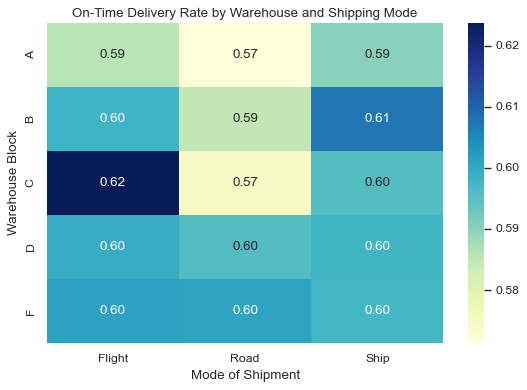

In [159]:
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("On-Time Delivery Rate by Warehouse and Shipping Mode")
plt.ylabel("Warehouse Block")
plt.xlabel("Mode of Shipment")
plt.show()

No significant difference in on-time delivery rate for different warehouse blocks using different shipments (Flight, Road, Sea).

---
----
----
------
---
----
-----
-----

## **11. Customer Segmentation for Delivery Analysis:**

In [161]:
data.head(4)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1


`Clustering` groups customers with similar characteristics. For delivery analysis, we can use features such as:

- **`Prior_purchases`** (number of previous purchases)

- **`Customer_rating`** (satisfaction score)

- **`Discount_offered`** (sensitivity to promotions)

- **`Gender`** (can be encoded numerically)

- **`Product_importance`** (can be encoded numerically)

- **`Customer_care_calls`** (engagement/complaints)

**2. Data Preparation for Clustering:**

Clustering algorithms (like `KMeans`) require:

- **`Numerical data`**: Convert categorical variables (e.g., `Gender`, `Product_importance`) to numbers using `one-hot encoding` or `label encoding`.

- **`No missing values`**: Fill or drop missing data.

- **`Feature scaling`**: `Standardize` or `normalize` features so all have similar ranges (important for distance-based algorithms).

In [165]:
data.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [175]:
data["Product_importance"].unique()

array(['low', 'medium', 'high'], dtype=object)

In [176]:
data["Gender"].unique()

array(['F', 'M'], dtype=object)

In [173]:
from sklearn.preprocessing import StandardScaler

# Select features for clustering
features = ['Prior_purchases', 'Customer_rating', 'Discount_offered', 'Customer_care_calls']
# Encode categorical variables if needed
data_encoded = pd.get_dummies(data[features + ['Gender', 'Product_importance']], drop_first=True)
data_encoded

,Prior_purchases,Customer_rating,Discount_offered,Customer_care_calls,Gender_M,Product_importance_low,Product_importance_medium
0,3,2,44,4,False,True,False
1,2,5,59,4,True,True,False
2,4,2,48,2,True,True,False
3,4,3,10,3,True,False,True
4,3,2,46,2,False,False,True
...,...,...,...,...,...,...,...
10994,5,1,1,4,False,False,True
10995,5,1,6,4,False,False,True
10996,5,4,4,5,False,True,False
10997,6,2,2,5,True,False,True


In [177]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_encoded)

In [178]:
X_scaled

array([[-0.37273475, -0.7007551 ,  1.88998336, ..., -0.99176046,
         1.03752512, -0.87249584],
       [-1.02942377,  1.42157771,  2.81563557, ...,  1.00830799,
         1.03752512, -0.87249584],
       [ 0.28395426, -0.7007551 ,  2.13682395, ...,  1.00830799,
         1.03752512, -0.87249584],
       ...,
       [ 0.94064328,  0.71413344, -0.57842252, ..., -0.99176046,
         1.03752512, -0.87249584],
       [ 1.5973323 , -0.7007551 , -0.70184282, ...,  1.00830799,
        -0.96383209,  1.14613726],
       [ 0.94064328,  1.42157771, -0.45500223, ..., -0.99176046,
         1.03752512, -0.87249584]], shape=(10999, 7))

**3. Apply Clustering Algorithms:**

Clustering is an **`unsupervised learning algorithm`** in machine learning that groups similar data points into clusters based on their features, **`without needing labeled data`**. The idea is to segment a dataset into subsets (clusters) where data points in the same group are more similar to each other than to those in other groups. This is widely used in `pattern recognition`, `market segmentation`, `social network analysis`, and `anomaly detection`.

The core logic behind clustering is **`distance or similarity`**. Most clustering algorithms use some form of distance metric (like `Euclidean distance`) to decide how close or far apart data points are. 

Clustering essentially performs **`segmentation`** by exploiting the **structure and distribution** of the data in its feature space. Data points that are close together in terms of feature similarity are placed in the same cluster. This segmentation helps uncover hidden patterns or natural groupings in the data.

Different algorithms use different strategies. **`Hierarchical clustering`** builds nested clusters by either merging or splitting clusters successively, while **`DBSCAN`** groups data based on density, identifying clusters of high-density and marking low-density points as noise or outliers.

**`KMeans`** is choosen for customer segmentation.

In [179]:
from sklearn.cluster import KMeans

# Choose number of clusters (e.g., 3)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to your data
data['Customer_Segment'] = clusters

In [180]:
data.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N', 'Customer_Segment'],
      dtype='object')

In [189]:
asd= data["Customer_Segment"].value_counts().reset_index()
asd

,Customer_Segment,count
0,0,4748
1,2,3876
2,1,2375


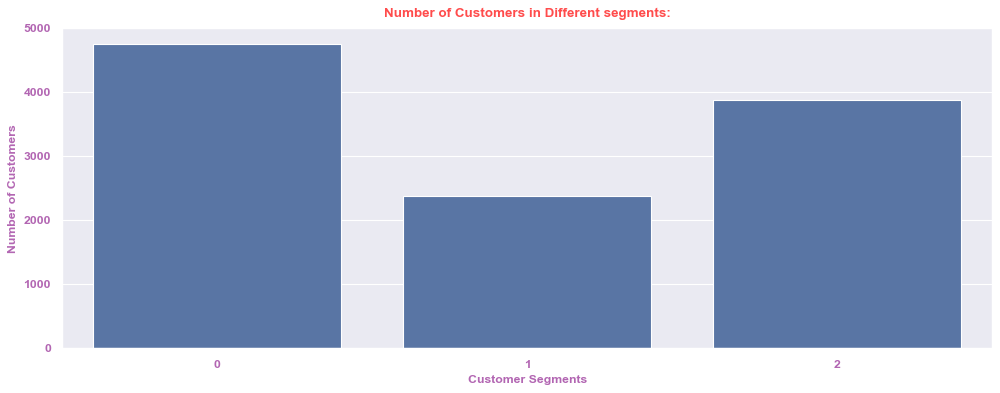

In [193]:
plt.figure(figsize=(15, 5))
sns.set_theme(context= "notebook", style= "darkgrid")
sns.barplot(data= asd, x= "Customer_Segment", y= "count")
plt.title("Number of Customers in Different segments:", color= "red", fontsize= 12, fontweight= "bold", pad= 10, alpha= 0.7)
plt.xlabel("Customer Segments", color= "purple", fontweight= "bold", alpha= 0.6, fontsize= 11)
plt.ylabel("Number of Customers", color= "purple", fontweight= "bold", alpha= 0.6, fontsize= 11)    
plt.xticks(color= "purple", fontweight= "bold", alpha= 0.6, fontsize= 11)
plt.yticks(color= "purple", fontweight= "bold", alpha= 0.6, fontsize= 11)
plt.show()

**4. Analyze Segments:**

We use `groupby` to analyze delivery performance by segment:

In [182]:
segment_performance = data.groupby('Customer_Segment')['Reached.on.Time_Y.N'].mean().reset_index()
print(segment_performance)

   Customer_Segment  Reached.on.Time_Y.N
0                 0             0.590564
1                 1             0.515368
2                 2             0.654025


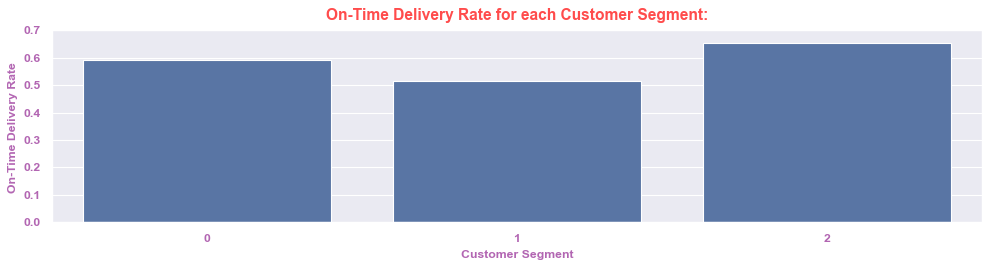

In [194]:
plt.figure(figsize=(15, 3))
sns.set_theme(context= "notebook", style= "darkgrid")
sns.barplot(data= segment_performance, x= "Customer_Segment", y= "Reached.on.Time_Y.N")
plt.title("On-Time Delivery Rate for each Customer Segment:", color= "red", fontsize= 14, fontweight= "bold", pad= 10, alpha= 0.7)
plt.xlabel("Customer Segment", color= "purple", fontweight= "bold", alpha= 0.6, fontsize= 11)
plt.ylabel("On-Time Delivery Rate", color= "purple", fontweight= "bold", alpha= 0.6, fontsize= 11)
plt.xticks(color= "purple", fontweight= "bold", alpha= 0.6, fontsize= 11)
plt.yticks(color= "purple", fontweight= "bold", alpha= 0.6, fontsize= 11)
plt.show()

In [195]:
data.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N', 'Customer_Segment'],
      dtype='object')

---
----
----
-----
----
----

### **12. Outlier and Anomaly Detection:**

In [242]:
data.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N', 'Customer_Segment', 'Anomaly', 'LOF_Anomaly'],
      dtype='object')

**1. Statistical Outlier Detection (IQR & Z-score):**

**IQR Method (for each numeric column):**

First, select numeric columns for analysis:

In [249]:
numeric_cols = data.select_dtypes(include=['int64', 'float64'])
numeric_cols.head(3)

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,4,2,177,3,44,1233,1
1,2,4,5,216,2,59,3088,1
2,3,2,2,183,4,48,3374,1


In [250]:
# Exclude ID column from analysis too:
numeric_cols = numeric_cols[[col for col in numeric_cols.columns if col != 'ID']]
# To do this we can also use drop() method: 
#numeric_cols= numeric_cols.drop("ID", axis= 1)

In [251]:
numeric_cols.columns

Index(['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
       'Prior_purchases', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

IQR measures the spread of the middle 50% of a dataset and is calculated as the difference between the third quartile (Q3) and the first quartile (Q1), i.e., **$IQR = Q3 - Q1$**. Any data point that falls **`below Q1 - 1.5 × IQR`** or **`above Q3 + 1.5 × IQR`** is considered an outlier. This method works well for datasets that are not heavily skewed and helps identify extreme values that differ significantly from the rest of the data.

In [252]:
outlier_indices = set()
for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_indices.update(data[(data[col] < lower) | (data[col] > upper)].index)
print(f"Total outliers detected by IQR: {len(outlier_indices)}")

Total outliers detected by IQR: 3028


Here, we have detected outlier data points throught the dataset and is not the number of outlier rows in the dataset.

**2. Z-score Method (for each numeric column):**

`Z-score` is a statistical method used to detect outliers by measuring how far a data point is from the mean in terms of standard deviations. The **z-score** of a value is calculated as:
**$z = (x - μ) / σ$**, where `x` is the data point, `μ` is the mean of the data, and `σ` is the standard deviation. A $z-score$ tells us how many standard deviations a point is away from the mean. Typically, if a value has a $z-score$ greater than 3 or less than -3, it is considered an **outlier**.

In outlier detection, z-scores help identify values that are unusually high or low compared to the rest of the dataset. This method works well when the data is **`normally distributed`**, as most values in a normal distribution lie within three standard deviations from the mean.

In [253]:
numeric_cols= numeric_cols.columns
numeric_cols

Index(['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
       'Prior_purchases', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [254]:
from scipy.stats import zscore

z_scores = data[numeric_cols].apply(zscore)
z_scores.head(3)

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,-0.047711,-0.700755,-0.690722,-0.372735,1.889983,-1.468240,0.822138
1,-0.047711,1.421578,0.120746,-1.029424,2.815636,-0.333893,0.822138
2,-1.799887,-0.700755,-0.565881,0.283954,2.136824,-0.159002,0.822138


In [255]:
z_outliers = (abs(z_scores) > 3).any(axis=1)
print(f"Total outliers detected by Z-score: {z_outliers.sum()}")

Total outliers detected by Z-score: 357


**3. Machine Learning-Based Anomaly Detection: Using `Isolation Forest`:**

- Isolation Forest is a tree-based algorithm specifically designed for outlier detection. It works by **`isolating data points`** instead of profiling normal instances. 

- The idea is that outliers are few and different, so they are easier to isolate. The algorithm randomly selects a feature and splits the data based on a random threshold. 

- This process continues recursively, forming a tree structure. Outliers tend to be isolated in fewer splits (shorter paths), while normal points require more splits (longer paths).

- In practice, we can use the `IsolationForest` class from scikit-learn. After fitting the model to our data, we can use the `.predict()` method, which returns `-1` for outliers and `1` for inliers. 

- It works well with high-dimensional data and does not assume any specific distribution, making it a robust choice for various real-world datasets. 

In [256]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.01, random_state=42)
anomaly_labels = iso.fit_predict(data[numeric_cols])
data['Anomaly'] = (anomaly_labels == -1)
print(f"Total anomalies detected by Isolation Forest: {data['Anomaly'].sum()}")

Total anomalies detected by Isolation Forest: 110


**4. Local Outlier Factor $(LOF)$:**

- Local Outlier Factor $(LOF)$ is a **`density-based`** method for detecting outliers by comparing the `local density of a point` to that of its `neighbors`. 

- The key idea is that outliers lie in regions with much lower density than their surrounding points. 

- `LOF` assigns a score to each data point based on how isolated it is with respect to the surrounding neighborhood.  A `higher LOF score` indicates a higher likelihood that the point is an outlier. 

- In Python, LOF is implemented using the `LocalOutlierFactor` class in scikit-learn. 

- We fit the model to our data and use the `.fit_predict()` method, which returns `-1` for outliers and `1` for inliers. We can adjust the `n_neighbors` parameter to control the size of the local neighborhood used in the comparison. LOF is especially useful when data has regions of varying density, as it adapts locally rather than using a global threshold.

In [257]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01)
lof_labels = lof.fit_predict(data[numeric_cols])
data['LOF_Anomaly'] = (lof_labels == -1)
print(f"Total anomalies detected by LOF: {data['LOF_Anomaly'].sum()}")

Total anomalies detected by LOF: 110


**`Example`: Scatter Plot with Anomalies Highlighted:**

We can plot scatter-plot between any two numeric columns and set hue to `Anomaly` to get dots differentiated by two color encodings, one represents outliers and the other represents inliers.

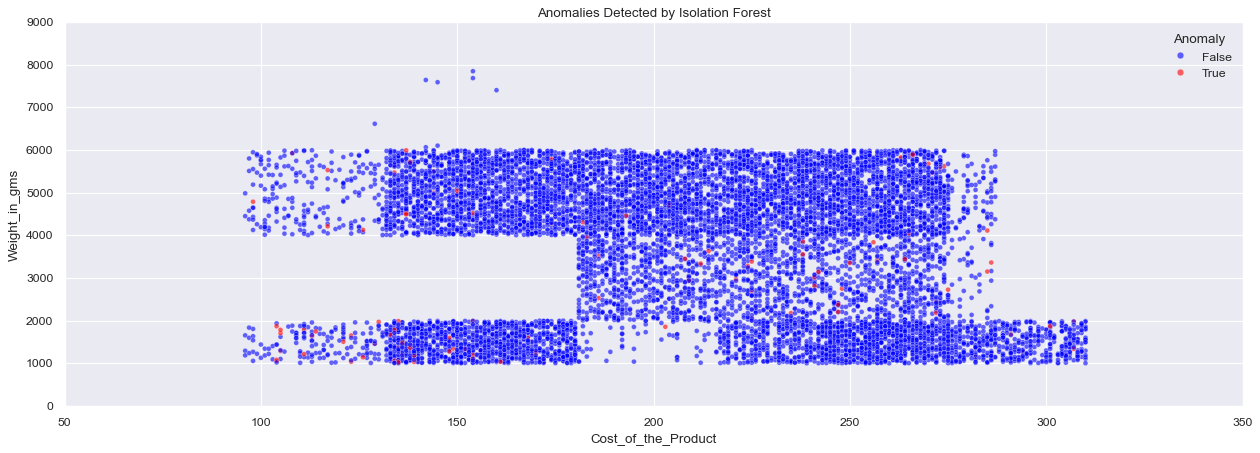

In [260]:
plt.figure(figsize=(19,6))

sns.scatterplot(
    x='Cost_of_the_Product', y='Weight_in_gms',
    data=data, hue='Anomaly', palette={False: 'blue', True: 'red'}, alpha=0.6
)
plt.title("Anomalies Detected by Isolation Forest")
plt.show()

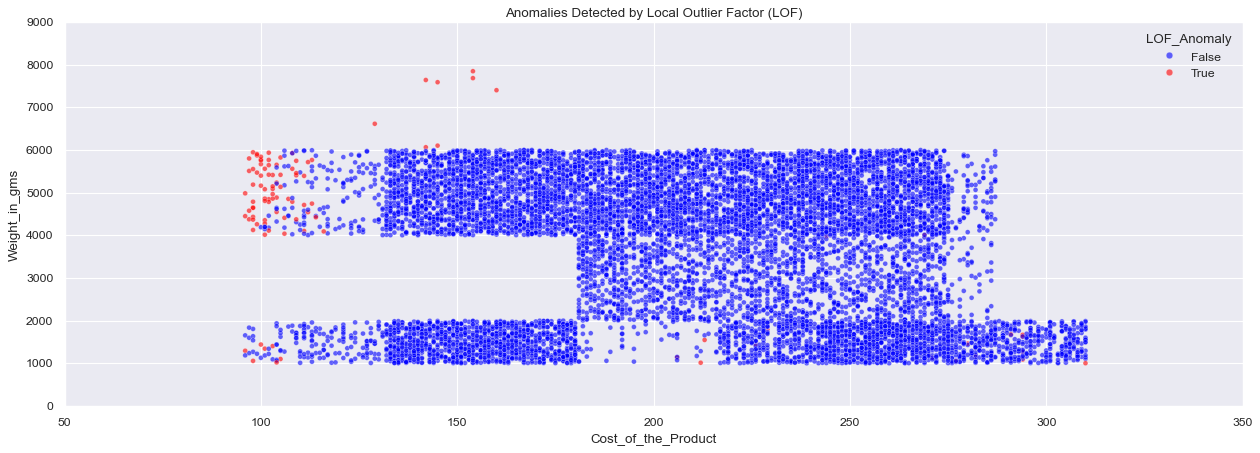

In [261]:
plt.figure(figsize=(19,6))

sns.scatterplot(
    x='Cost_of_the_Product', y='Weight_in_gms',
    data=data, hue='LOF_Anomaly', palette={False: 'blue', True: 'red'}, alpha=0.6
)
plt.title("Anomalies Detected by Local Outlier Factor (LOF)")
plt.show()

Here, `Local Outlier Factor` $(LOF)$ seems to outperform all other detection approachs as it perfectly identifies unusual data values.

----
----
----
----
---

### **15. Performance Benchmarking and Gap Analysis:**

**What we do**: Compare current performance against targets and identify improvement opportunities for each operational dimension.      

**Implementation approach**: Set performance benchmarks based on best-performing segments, calculate performance gaps for each warehouse/shipping mode combination, and create gap analysis visualizations to prioritize improvement areas.